# Klasifikasi Sampah Hierarkis

Notebook ini menggunakan 2 model secara bertingkat (hierarki):

1. **Model 1** (`model_organik_anorganik.h5`) → Klasifikasi **Organik** vs **Anorganik**
2. **Model 2** (`binary_best_model.keras`) → Jika Anorganik, klasifikasi **Recyclable (Anorganik)** vs **Non-Recyclable (Residu)**

### Alur:
```
Gambar → Model 1 → Organik?     → Label: ORGANIK
                  → Anorganik?   → Model 2 → Recyclable?     → Label: ANORGANIK
                                           → Non-Recyclable? → Label: RESIDU
```

## 1. Import Libraries

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from pathlib import Path

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU available: []


## 2. Load Kedua Model

In [3]:
# Path model
MODEL1_PATH = r"C:\Users\rika\Downloads\tanin\modelnya_sapi_lembang\model_organik_anorganik.h5"
MODEL2_PATH = r"C:\Users\rika\Downloads\tanin\modelnya_sapi_lembang\binary_best_model.keras"

# Load Model 1: Organik vs Anorganik
# Input : (224, 224, 3), rescale 1/255
# Output: softmax 2 kelas → {Anorganik: 0, Organik: 1}
print("Loading Model 1 (Organik vs Anorganik)...")
model1 = load_model(MODEL1_PATH)
print(f"  Input shape : {model1.input_shape}")
print(f"  Output shape: {model1.output_shape}")

# Load Model 2: Non-Recyclable (Residu) vs Recyclable (Anorganik)
# Input : (224, 224, 3), rescale 1/255
# Output: sigmoid 1 neuron → <0.5 = Non-Recyclable (Residu), >=0.5 = Recyclable (Anorganik)
print("\nLoading Model 2 (Residu vs Recyclable)...")
model2 = load_model(MODEL2_PATH)
print(f"  Input shape : {model2.input_shape}")
print(f"  Output shape: {model2.output_shape}")

print("\n✅ Kedua model berhasil dimuat!")

Loading Model 1 (Organik vs Anorganik)...


  Input shape : (None, 224, 224, 3)
  Output shape: (None, 2)

Loading Model 2 (Residu vs Recyclable)...
  Input shape : (None, 224, 224, 3)
  Output shape: (None, 1)

✅ Kedua model berhasil dimuat!


## 3. Konfigurasi

In [4]:
IMG_SIZE = (224, 224)

# Class mapping Model 1 (dari flow_from_directory, urutan alfabet)
MODEL1_CLASSES = {0: 'Anorganik', 1: 'Organik'}

# Class mapping Model 2 (binary sigmoid)
# < 0.5 → Non-Recyclable (Residu)
# >= 0.5 → Recyclable (Anorganik biasa)
MODEL2_CLASSES = {0: 'Residu', 1: 'Anorganik'}

# Path test data
TESDATA_DIR = r"C:\Users\rika\Downloads\tanin\modelnya_sapi_lembang\tesdata"

# Label akhir (3 kelas hierarki)
FINAL_LABELS = ['Organik', 'Anorganik', 'Residu']
LABEL_COLORS = {'Organik': '#2ecc71', 'Anorganik': '#3498db', 'Residu': '#e74c3c'}

print("Konfigurasi:")
print(f"  Image Size    : {IMG_SIZE}")
print(f"  Model 1 kelas : {MODEL1_CLASSES}")
print(f"  Model 2 kelas : {MODEL2_CLASSES}")
print(f"  Test data dir : {TESDATA_DIR}")

Konfigurasi:
  Image Size    : (224, 224)
  Model 1 kelas : {0: 'Anorganik', 1: 'Organik'}
  Model 2 kelas : {0: 'Residu', 1: 'Anorganik'}
  Test data dir : C:\Users\rika\Downloads\tanin\modelnya_sapi_lembang\tesdata


## 4. Fungsi Prediksi Hierarkis

In [5]:
def preprocess_image(image_path, target_size=IMG_SIZE):
    """Load dan preprocess gambar untuk prediksi."""
    img = load_img(image_path, target_size=target_size)
    img_array = img_to_array(img) / 255.0  # Normalisasi
    img_batch = np.expand_dims(img_array, axis=0)  # Tambah dimensi batch
    return img, img_batch


def predict_hierarchical(image_path, model1, model2, verbose=False):
    """
    Prediksi hierarkis:
      Step 1: Model 1 → Organik atau Anorganik?
      Step 2: Jika Anorganik → Model 2 → Residu atau Anorganik (Recyclable)?
    
    Returns:
        dict dengan keys: final_label, model1_pred, model1_conf, 
                          model2_pred (jika ada), model2_conf (jika ada)
    """
    img, img_batch = preprocess_image(image_path)
    
    # === STEP 1: Organik vs Anorganik ===
    pred1 = model1.predict(img_batch, verbose=0)
    pred1_idx = np.argmax(pred1[0])
    pred1_label = MODEL1_CLASSES[pred1_idx]
    pred1_conf = pred1[0][pred1_idx] * 100
    
    result = {
        'image_path': image_path,
        'model1_pred': pred1_label,
        'model1_conf': pred1_conf,
        'model1_probs': {MODEL1_CLASSES[i]: float(pred1[0][i]) for i in range(len(pred1[0]))},
        'model2_pred': None,
        'model2_conf': None,
        'model2_probs': None,
        'final_label': None
    }
    
    if pred1_label == 'Organik':
        # Organik → langsung selesai
        result['final_label'] = 'Organik'
        if verbose:
            print(f"  Model 1: {pred1_label} ({pred1_conf:.1f}%) → Final: ORGANIK")
    else:
        # Anorganik → lanjut ke Model 2
        # === STEP 2: Residu vs Recyclable (Anorganik) ===
        pred2 = model2.predict(img_batch, verbose=0)
        prob2 = pred2[0][0]  # sigmoid output
        
        if prob2 >= 0.5:
            pred2_label = 'Anorganik'  # Recyclable
            pred2_conf = prob2 * 100
        else:
            pred2_label = 'Residu'  # Non-Recyclable
            pred2_conf = (1 - prob2) * 100
        
        result['model2_pred'] = pred2_label
        result['model2_conf'] = pred2_conf
        result['model2_probs'] = {
            'Residu (Non-Recyclable)': float(1 - prob2),
            'Anorganik (Recyclable)': float(prob2)
        }
        result['final_label'] = pred2_label
        
        if verbose:
            print(f"  Model 1: {pred1_label} ({pred1_conf:.1f}%) → Model 2: {pred2_label} ({pred2_conf:.1f}%) → Final: {pred2_label.upper()}")
    
    return result


print("✅ Fungsi prediksi hierarkis siap digunakan.")

✅ Fungsi prediksi hierarkis siap digunakan.


In [6]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import serial

from collections import deque
from PIL import Image

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from pathlib import Path

In [7]:
## 5. Fungsi Prediksi Webcam
def predict_frame(frame, model1, model2):
    """
    Prediksi gambar dari webcam menggunakan
    model klasifikasi hierarkis.
    """

    # BGR → RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Convert ke PIL Image
    img = Image.fromarray(frame_rgb)

    # Resize
    img = img.resize(IMG_SIZE)

    # Normalisasi
    img_array = img_to_array(img) / 255.0

    # Tambahkan batch dimension
    img_batch = np.expand_dims(img_array, axis=0)

    # =========================
    # MODEL 1
    # =========================

    pred1 = model1.predict(img_batch, verbose=0)

    pred1_idx = np.argmax(pred1[0])
    pred1_label = MODEL1_CLASSES[pred1_idx]
    pred1_conf = pred1[0][pred1_idx] * 100

    # =========================
    # HIERARCHICAL DECISION
    # =========================

    if pred1_label == "Organik":

        final_label = "Organik"
        final_conf = pred1_conf

    else:

        # Model 2
        pred2 = model2.predict(img_batch, verbose=0)

        prob2 = pred2[0][0]

        if prob2 >= 0.5:

            final_label = "Anorganik"
            final_conf = prob2 * 100

        else:

            final_label = "Residu"
            final_conf = (1 - prob2) * 100

    return final_label, final_conf

In [8]:
## 6. Koneksi Arduino
ARDUINO_PORT = "COM7"
ARDUINO_BAUDRATE = 9600

arduino = serial.Serial(
    ARDUINO_PORT,
    ARDUINO_BAUDRATE,
    timeout=1
)

time.sleep(2)

print("✅ Arduino berhasil terhubung!")
print(f"Port: {ARDUINO_PORT}")

✅ Arduino berhasil terhubung!
Port: COM7


In [9]:
def send_to_arduino(label):

    if label == "Organik":
        command = "ORGANIK"

    elif label == "Anorganik":
        command = "ANORGANIK"

    elif label == "Residu":
        command = "RESIDU"

    else:
        print(f"⚠️ Label tidak dikenal: {label}")
        return

    arduino.write((command + "\n").encode())

    print(f"📤 Mengirim ke Arduino: {command}")

In [10]:
## 7. Konfigurasi Sistem Real-Time
from collections import deque


STABLE_FRAMES = 5

# Berapa detik sistem menunggu
# sebelum siap menerima objek berikutnya
RESET_DELAY = 3

prediction_history = deque(
    maxlen=STABLE_FRAMES
)

object_confirmed = False

last_sent_label = None
last_send_time = 0

In [ ]:
## 8. Jalankan Sistem Real-Time
# ==========================================
# BUKA WEBCAM
# ==========================================

cap = cv2.VideoCapture(0)

if not cap.isOpened():

    print("❌ Webcam tidak dapat dibuka")

else:

    print("✅ Webcam siap!")
    print("Tekan Q untuk keluar.")
    
    # ======================================
    # LOOP UTAMA
    # ======================================

    while True:

        ret, frame = cap.read()

        if not ret:

            print("❌ Gagal mengambil frame")
            break

        # ==================================
        # PREDIKSI
        # ==================================

        label, confidence = predict_frame(
            frame,
            model1,
            model2
        )

        prediction_history.append(label)

        # ==================================
        # CEK PREDIKSI STABIL
        # ==================================

        stable = (
            len(prediction_history) == STABLE_FRAMES
            and len(set(prediction_history)) == 1
        )

        # ==================================
        # KONFIRMASI OBJEK
        # ==================================

        if stable and not object_confirmed:

            confirmed_label = prediction_history[-1]

            print()
            print("=" * 40)
            print("✅ OBJEK TERKONFIRMASI")
            print(f"Jenis      : {confirmed_label}")
            print(f"Confidence : {confidence:.1f}%")
            print("=" * 40)

            # Kirim ke Arduino
            send_to_arduino(confirmed_label)

            object_confirmed = True
            last_sent_label = confirmed_label
            last_send_time = time.time()

            prediction_history.clear()

        # ==================================
        # RESET OTOMATIS
        # ==================================

        if object_confirmed:

            elapsed_time = (
                time.time() - last_send_time
            )

            remaining = max(
                0,
                RESET_DELAY - elapsed_time
            )

            if elapsed_time >= RESET_DELAY:

                object_confirmed = False
                last_sent_label = None
                prediction_history.clear()

                print(
                    "🔄 Sistem siap menerima "
                    "objek berikutnya."
                )

        # ==================================
        # DISPLAY PREDICTION
        # ==================================

        text = (
            f"{label} "
            f"({confidence:.1f}%)"
        )

        cv2.putText(
            frame,
            text,
            (30, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2
        )

        # ==================================
        # DISPLAY STATUS
        # ==================================

        if object_confirmed:

            elapsed_time = (
                time.time() - last_send_time
            )

            remaining = max(
                0,
                RESET_DELAY - elapsed_time
            )

            status_text = (
                f"WAITING... "
                f"{remaining:.1f}s"
            )

        else:

            status_text = (
                f"DETECTING "
                f"{len(prediction_history)}"
                f"/{STABLE_FRAMES}"
            )

        cv2.putText(
            frame,
            status_text,
            (30, 90),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 0),
            2
        )

        # ==================================
        # SHOW WEBCAM
        # ==================================

        cv2.imshow(
            "SEGRATRUK - Waste Classification",
            frame
        )

        # ==================================
        # KEYBOARD
        # ==================================

        key = cv2.waitKey(1) & 0xFF

        if key == ord("q"):

            print("🛑 Sistem dihentikan.")
            break

        elif key == ord("r"):

            prediction_history.clear()

            object_confirmed = False
            last_sent_label = None

            print("🔄 Manual reset.")

✅ Webcam siap!
Tekan Q untuk keluar.

✅ OBJEK TERKONFIRMASI
Jenis      : Anorganik
Confidence : 67.4%
📤 Mengirim ke Arduino: ANORGANIK
🔄 Sistem siap menerima objek berikutnya.

✅ OBJEK TERKONFIRMASI
Jenis      : Anorganik
Confidence : 90.5%
📤 Mengirim ke Arduino: ANORGANIK
🔄 Sistem siap menerima objek berikutnya.

✅ OBJEK TERKONFIRMASI
Jenis      : Residu
Confidence : 81.8%
📤 Mengirim ke Arduino: RESIDU
🔄 Sistem siap menerima objek berikutnya.

✅ OBJEK TERKONFIRMASI
Jenis      : Residu
Confidence : 51.5%
📤 Mengirim ke Arduino: RESIDU
🔄 Sistem siap menerima objek berikutnya.

✅ OBJEK TERKONFIRMASI
Jenis      : Residu
Confidence : 78.7%
📤 Mengirim ke Arduino: RESIDU
🔄 Sistem siap menerima objek berikutnya.

✅ OBJEK TERKONFIRMASI
Jenis      : Residu
Confidence : 52.2%
📤 Mengirim ke Arduino: RESIDU
🔄 Sistem siap menerima objek berikutnya.

✅ OBJEK TERKONFIRMASI
Jenis      : Anorganik
Confidence : 63.5%
📤 Mengirim ke Arduino: ANORGANIK
🔄 Sistem siap menerima objek berikutnya.

✅ OBJEK TERKO

SerialException: WriteFile failed (PermissionError(13, 'Access is denied.', None, 5))

: 

In [ ]:
%pip install pyserial

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import serial
import time

arduino = serial.Serial("COM7", 9600, timeout=1)
time.sleep(2)

In [ ]:
#test
%pip install opencv-python pyserial

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   -------- ------------------------------- 2.6/12.6 MB 19.6 MB/s eta 0:00:01
   ------------------------- -------------- 8.1/12.6 MB 23.7 MB/s eta 0:00:01
   ---------------------------------------  12.6/12.6 MB 24.8 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 22.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.utils import img_to_array
from PIL import Image

In [ ]:
def predict_frame(frame, model1, model2):

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    img = Image.fromarray(frame_rgb)
    img = img.resize((224, 224))

    img_array = img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # Model 1
    pred1 = model1.predict(img_batch, verbose=0)

    pred1_idx = np.argmax(pred1[0])
    pred1_label = MODEL1_CLASSES[pred1_idx]
    pred1_conf = pred1[0][pred1_idx] * 100

    # Jika Organik
    if pred1_label == "Organik":

        final_label = "Organik"
        final_conf = pred1_conf

    # Jika Anorganik → Model 2
    else:

        pred2 = model2.predict(img_batch, verbose=0)

        prob2 = pred2[0][0]

        if prob2 >= 0.5:
            final_label = "Anorganik"
            final_conf = prob2 * 100
        else:
            final_label = "Residu"
            final_conf = (1 - prob2) * 100

    return final_label, final_conf

In [ ]:
while True:
    ret, frame = cap.read()

    if not ret:
        print("❌ Gagal mengambil frame")
        break

    # ==============================
    # PREDIKSI
    # ==============================

    label, confidence = predict_frame(
        frame,
        model1,
        model2
    )

    prediction_history.append(label)

    # ==============================
    # CEK STABILITAS PREDIKSI
    # ==============================

    stable = (
        len(prediction_history) == STABLE_FRAMES
        and len(set(prediction_history)) == 1
    )

    # ==============================
    # KIRIM KE ARDUINO
    # ==============================

    if stable and not object_confirmed:

        confirmed_label = prediction_history[-1]

        print()
        print("================================")
        print("✅ OBJEK TERKONFIRMASI")
        print(f"Jenis     : {confirmed_label}")
        print(f"Confidence: {confidence:.1f}%")
        print("================================")

        send_to_arduino(confirmed_label)

        object_confirmed = True
        last_sent_label = confirmed_label

        # Catat waktu ketika command dikirim
        last_send_time = time.time()

        # Bersihkan history
        prediction_history.clear()

    # ==============================
    # RESET OTOMATIS
    # ==============================

    if object_confirmed:

        elapsed_time = time.time() - last_send_time

        remaining = RESET_DELAY - elapsed_time

        if elapsed_time >= RESET_DELAY:

            object_confirmed = False
            last_sent_label = None
            prediction_history.clear()

            print()
            print("🔄 Sistem siap menerima objek berikutnya.")
            print()

    # ==============================
    # TAMPILAN WEBCAM
    # ==============================

    text = f"{label} ({confidence:.1f}%)"

    cv2.putText(
        frame,
        text,
        (30, 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    # Status
    if object_confirmed:

        elapsed_time = time.time() - last_send_time
        remaining = max(0, RESET_DELAY - elapsed_time)

        status_text = f"WAITING... {remaining:.1f}s"

    else:

        status_text = (
            f"DETECTING "
            f"{len(prediction_history)}/{STABLE_FRAMES}"
        )

    cv2.putText(
        frame,
        status_text,
        (30, 90),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 0),
        2
    )

    # ==============================
    # TAMPILKAN WEBCAM
    # ==============================

    cv2.imshow(
        "SEGRATRUK - Waste Classification",
        frame
    )

    # ==============================
    # KEYBOARD
    # ==============================

    key = cv2.waitKey(1) & 0xFF

    # Q = keluar
    if key == ord("q"):
        break

    # R = manual reset jika diperlukan
    if key == ord("r"):

        prediction_history.clear()

        object_confirmed = False
        last_sent_label = None

        print("🔄 Manual reset.")


✅ OBJEK TERKONFIRMASI
Jenis     : Anorganik
Confidence: 79.6%


PortNotOpenError: Attempting to use a port that is not open

: 

## 5. Kumpulkan Test Data

In [ ]:
valid_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}

test_data = []  # list of (path, true_label)

for folder_name in ['organik', 'anorganik', 'residu']:
    folder_path = os.path.join(TESDATA_DIR, folder_name)
    if not os.path.isdir(folder_path):
        print(f"⚠️ Folder tidak ditemukan: {folder_path}")
        continue
    
    # Label = nama folder (capitalize)
    true_label = folder_name.capitalize()  # organik → Organik, anorganik → Anorganik, residu → Residu
    
    files = [f for f in os.listdir(folder_path) 
             if os.path.isfile(os.path.join(folder_path, f)) 
             and os.path.splitext(f)[1].lower() in valid_ext]
    
    for f in sorted(files):
        test_data.append((os.path.join(folder_path, f), true_label))
    
    print(f"  {true_label:10}: {len(files)} gambar")

print(f"\nTotal test data: {len(test_data)} gambar")

  Organik   : 37 gambar
  Anorganik : 18 gambar
  Residu    : 16 gambar

Total test data: 71 gambar


## 6. Jalankan Prediksi pada Seluruh Test Data

In [ ]:
results = []
correct = 0
total = len(test_data)

print(f"Memproses {total} gambar...\n")

for i, (img_path, true_label) in enumerate(test_data):
    try:
        result = predict_hierarchical(img_path, model1, model2, verbose=False)
        result['true_label'] = true_label
        result['correct'] = (result['final_label'] == true_label)
        results.append(result)
        
        if result['correct']:
            correct += 1
    except Exception as e:
        print(f"  ❌ Error pada {os.path.basename(img_path)}: {e}")
        results.append({
            'image_path': img_path, 'true_label': true_label, 
            'final_label': 'ERROR', 'correct': False
        })

    # Progress setiap 25 gambar
    if (i + 1) % 25 == 0 or (i + 1) == total:
        print(f"  Processed: {i+1}/{total}")

print(f"\n{'='*60}")
print(f"OVERALL ACCURACY: {correct}/{total} = {correct/total*100:.2f}%")
print(f"{'='*60}")

Memproses 71 gambar...

  Processed: 25/71
  Processed: 50/71
  Processed: 71/71

OVERALL ACCURACY: 66/71 = 92.96%


## 7. Evaluasi Detail per Kelas

Note: you may need to restart the kernel to use updated packages.
CLASSIFICATION REPORT (Hierarkis)
              precision    recall  f1-score   support

     Organik       1.00      0.89      0.94        18
   Anorganik       0.95      0.97      0.96        37
      Residu       0.82      0.88      0.85        16

    accuracy                           0.93        71
   macro avg       0.92      0.91      0.92        71
weighted avg       0.93      0.93      0.93        71

Akurasi per kelas:
  Organik   : 36/37 = 97.3%
  Anorganik : 16/18 = 88.9%
  Residu    : 14/16 = 87.5%



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


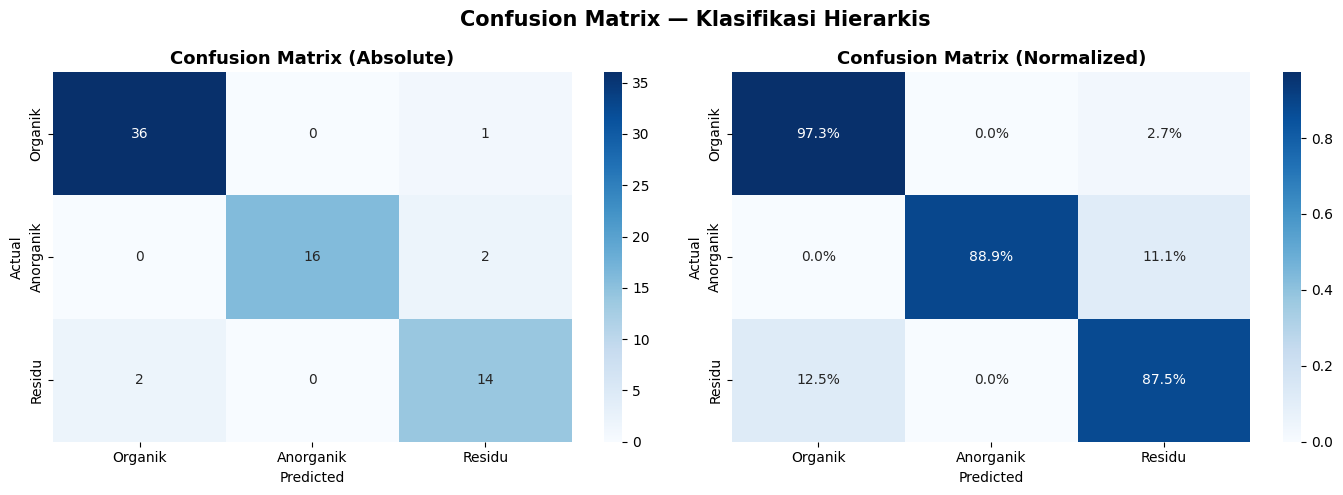

In [ ]:
%pip install seaborn
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = [r['true_label'] for r in results if r['final_label'] != 'ERROR']
y_pred = [r['final_label'] for r in results if r['final_label'] != 'ERROR']

# Classification Report
print("=" * 60)
print("CLASSIFICATION REPORT (Hierarkis)")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=FINAL_LABELS, zero_division=0))

# Akurasi per kelas
print("Akurasi per kelas:")
for label in FINAL_LABELS:
    mask = [t == label for t in y_true]
    if sum(mask) > 0:
        correct_cls = sum(1 for t, p in zip(y_true, y_pred) if t == label and p == label)
        total_cls = sum(mask)
        print(f"  {label:10}: {correct_cls}/{total_cls} = {correct_cls/total_cls*100:.1f}%")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=FINAL_LABELS)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=FINAL_LABELS, yticklabels=FINAL_LABELS, ax=ax1)
ax1.set_title('Confusion Matrix (Absolute)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=FINAL_LABELS, yticklabels=FINAL_LABELS, ax=ax2)
ax2.set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.suptitle('Confusion Matrix — Klasifikasi Hierarkis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Analisis Alur Hierarki

In [ ]:
# Analisis keputusan di setiap tahap
print("=" * 60)
print("ANALISIS ALUR HIERARKI")
print("=" * 60)

valid_results = [r for r in results if r['final_label'] != 'ERROR']

# Tahap 1: Model 1
m1_organik = [r for r in valid_results if r['model1_pred'] == 'Organik']
m1_anorganik = [r for r in valid_results if r['model1_pred'] == 'Anorganik']

print(f"\n📊 Model 1 (Organik vs Anorganik):")
print(f"  → Diklasifikasikan Organik  : {len(m1_organik)} gambar")
print(f"  → Diklasifikasikan Anorganik: {len(m1_anorganik)} gambar (dilanjutkan ke Model 2)")

# Breakdown Model 1 per true label
print(f"\n  Breakdown per label asli:")
for label in FINAL_LABELS:
    subset = [r for r in valid_results if r['true_label'] == label]
    as_org = sum(1 for r in subset if r['model1_pred'] == 'Organik')
    as_anorg = sum(1 for r in subset if r['model1_pred'] == 'Anorganik')
    print(f"    {label:10} ({len(subset):3} total): Model1→Organik={as_org}, Model1→Anorganik={as_anorg}")

# Tahap 2: Model 2 (hanya yang masuk Anorganik di Model 1)
if m1_anorganik:
    m2_recyclable = [r for r in m1_anorganik if r['model2_pred'] == 'Anorganik']
    m2_residu = [r for r in m1_anorganik if r['model2_pred'] == 'Residu']
    
    print(f"\n📊 Model 2 (Residu vs Recyclable) — dari {len(m1_anorganik)} gambar:")
    print(f"  → Recyclable (Anorganik)    : {len(m2_recyclable)} gambar")
    print(f"  → Non-Recyclable (Residu)   : {len(m2_residu)} gambar")
    
    print(f"\n  Breakdown per label asli:")
    for label in FINAL_LABELS:
        subset = [r for r in m1_anorganik if r['true_label'] == label]
        if len(subset) == 0:
            continue
        as_rec = sum(1 for r in subset if r['model2_pred'] == 'Anorganik')
        as_res = sum(1 for r in subset if r['model2_pred'] == 'Residu')
        print(f"    {label:10} ({len(subset):3} masuk M2): Model2→Anorganik={as_rec}, Model2→Residu={as_res}")

ANALISIS ALUR HIERARKI

📊 Model 1 (Organik vs Anorganik):
  → Diklasifikasikan Organik  : 38 gambar
  → Diklasifikasikan Anorganik: 33 gambar (dilanjutkan ke Model 2)

  Breakdown per label asli:
    Organik    ( 37 total): Model1→Organik=36, Model1→Anorganik=1
    Anorganik  ( 18 total): Model1→Organik=0, Model1→Anorganik=18
    Residu     ( 16 total): Model1→Organik=2, Model1→Anorganik=14

📊 Model 2 (Residu vs Recyclable) — dari 33 gambar:
  → Recyclable (Anorganik)    : 16 gambar
  → Non-Recyclable (Residu)   : 17 gambar

  Breakdown per label asli:
    Organik    (  1 masuk M2): Model2→Anorganik=0, Model2→Residu=1
    Anorganik  ( 18 masuk M2): Model2→Anorganik=16, Model2→Residu=2
    Residu     ( 14 masuk M2): Model2→Anorganik=0, Model2→Residu=14


## 9. Visualisasi Sample Prediksi

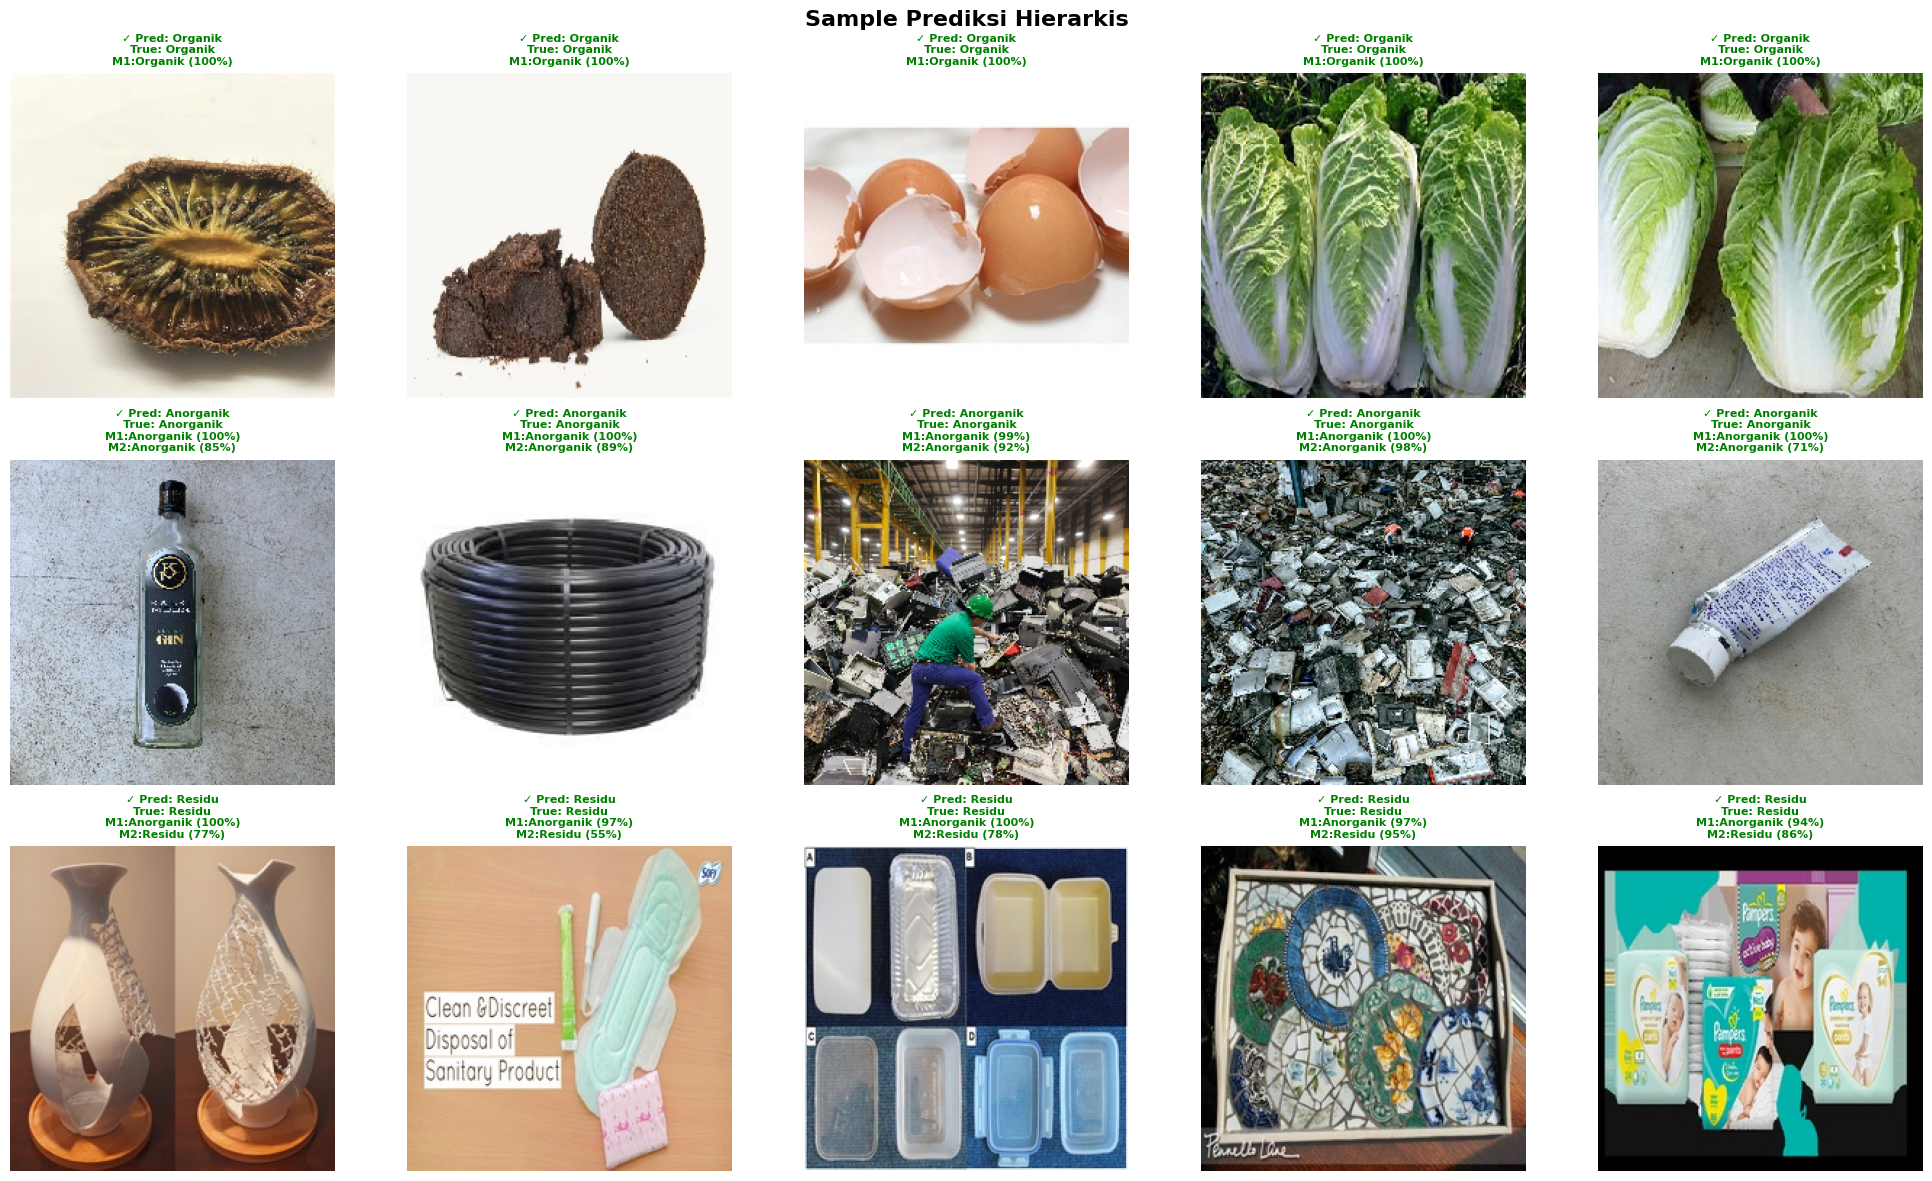

In [ ]:
import random
random.seed(42)

# Ambil sample dari setiap kelas (max 5 per kelas)
samples = []
for label in FINAL_LABELS:
    label_results = [r for r in valid_results if r['true_label'] == label]
    n_sample = min(5, len(label_results))
    samples.extend(random.sample(label_results, n_sample))

n_cols = 5
n_rows = (len(samples) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
if n_rows == 1:
    axes = [axes]
axes_flat = [ax for row in axes for ax in (row if hasattr(row, '__iter__') else [row])]

for idx, r in enumerate(samples):
    ax = axes_flat[idx]
    try:
        img = load_img(r['image_path'], target_size=IMG_SIZE)
        ax.imshow(img)
    except:
        ax.text(0.5, 0.5, 'Error', ha='center', va='center', transform=ax.transAxes)
    
    is_correct = r['correct']
    symbol = '✓' if is_correct else '✗'
    color = 'green' if is_correct else 'red'
    
    # Bangun info alur
    m1_info = f"M1:{r.get('model1_pred','?')} ({r.get('model1_conf',0):.0f}%)"
    if r.get('model2_pred'):
        m2_info = f"\nM2:{r['model2_pred']} ({r['model2_conf']:.0f}%)"
    else:
        m2_info = ''
    
    ax.set_title(
        f"{symbol} Pred: {r['final_label']}\nTrue: {r['true_label']}\n{m1_info}{m2_info}",
        fontsize=8, color=color, fontweight='bold'
    )
    ax.axis('off')

# Sembunyikan axes kosong
for idx in range(len(samples), len(axes_flat)):
    axes_flat[idx].axis('off')

plt.suptitle('Sample Prediksi Hierarkis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Detail Prediksi yang Salah

In [ ]:
wrong = [r for r in valid_results if not r['correct']]
print(f"Total prediksi salah: {len(wrong)}/{len(valid_results)}\n")

for r in wrong:
    fname = os.path.basename(r['image_path'])
    m1 = f"M1:{r['model1_pred']}({r['model1_conf']:.1f}%)"
    if r.get('model2_pred'):
        m2 = f" → M2:{r['model2_pred']}({r['model2_conf']:.1f}%)"
    else:
        m2 = ''
    print(f"  {fname[:40]:40} | True: {r['true_label']:10} | Pred: {r['final_label']:10} | {m1}{m2}")

Total prediksi salah: 5/71

  Residu_train_00056.jpg                   | True: Organik    | Pred: Residu     | M1:Anorganik(86.0%) → M2:Residu(65.5%)
  _صنایع تولیدی ایلیا پلاست 🇮🇷_ on Instagr | True: Anorganik  | Pred: Residu     | M1:Anorganik(100.0%) → M2:Residu(97.4%)
  【コラム】使い捨てでも環境にやさしく。バガスからできた容器特集。.jpeg    | True: Anorganik  | Pred: Residu     | M1:Anorganik(100.0%) → M2:Residu(92.4%)
  Residu_test_00034.jpg                    | True: Residu     | Pred: Organik    | M1:Organik(99.7%)
  Residu_test_00052.jpg                    | True: Residu     | Pred: Organik    | M1:Organik(87.2%)


---
## 11. Precision, Recall, F1-Score — Bar Chart per Kelas

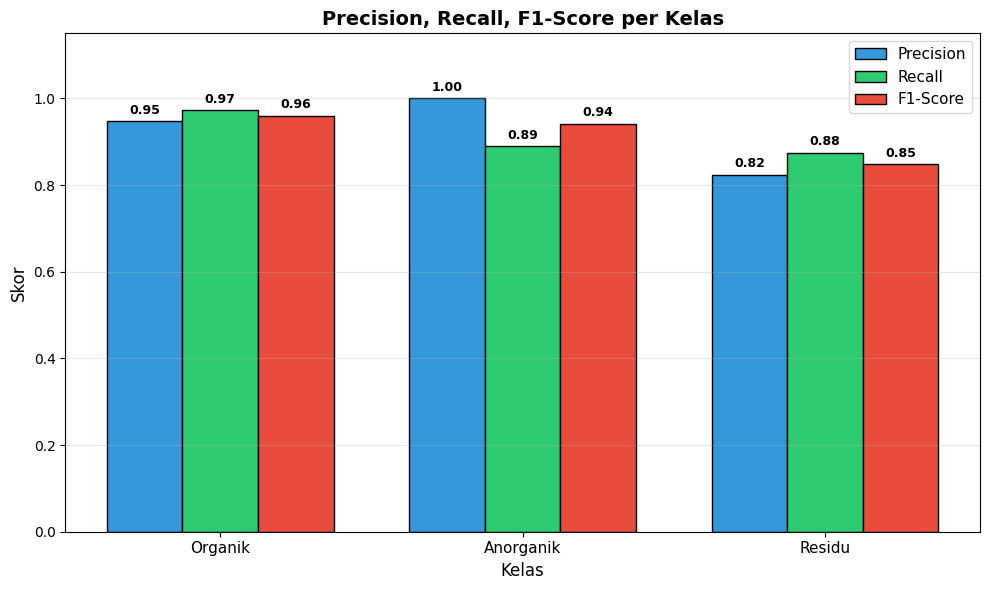

Kelas         Precision     Recall   F1-Score    Support
------------------------------------------------------
Organik          0.9474     0.9730     0.9600         37
Anorganik        1.0000     0.8889     0.9412         18
Residu           0.8235     0.8750     0.8485         16


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=FINAL_LABELS, zero_division=0
)

x_pos = np.arange(len(FINAL_LABELS))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x_pos - bar_width, precision, bar_width, label='Precision', color='#3498db', edgecolor='black')
bars2 = ax.bar(x_pos, recall, bar_width, label='Recall', color='#2ecc71', edgecolor='black')
bars3 = ax.bar(x_pos + bar_width, f1, bar_width, label='F1-Score', color='#e74c3c', edgecolor='black')

# Tambahkan nilai di atas bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Kelas', fontsize=12)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Precision, Recall, F1-Score per Kelas', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(FINAL_LABELS, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Tabel ringkasan
print(f"{'Kelas':12} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
print("-" * 54)
for i, label in enumerate(FINAL_LABELS):
    print(f"{label:12} {precision[i]:>10.4f} {recall[i]:>10.4f} {f1[i]:>10.4f} {support[i]:>10}")

## 12. Distribusi Data Test vs Prediksi

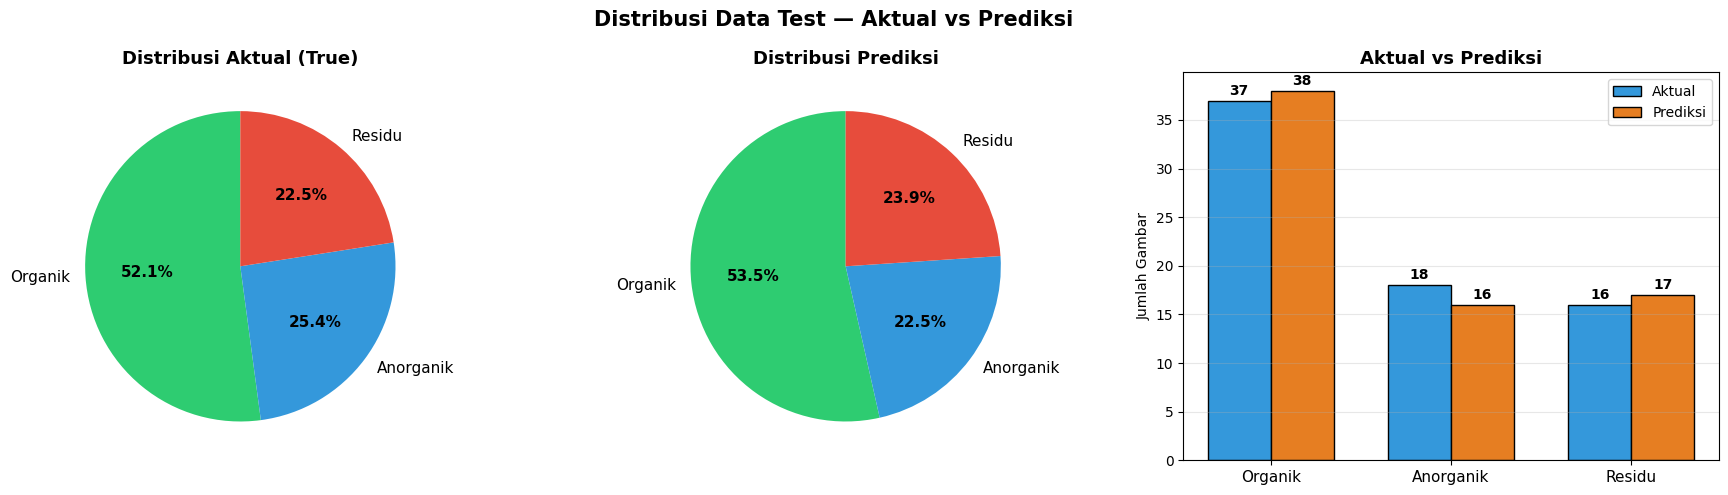

In [ ]:
from collections import Counter

true_counts = Counter(y_true)
pred_counts = Counter(y_pred)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie chart: distribusi data test (actual)
ax1 = axes[0]
sizes_true = [true_counts.get(l, 0) for l in FINAL_LABELS]
colors_pie = [LABEL_COLORS[l] for l in FINAL_LABELS]
wedges1, texts1, autotexts1 = ax1.pie(
    sizes_true, labels=FINAL_LABELS, autopct='%1.1f%%',
    colors=colors_pie, startangle=90, textprops={'fontsize': 11}
)
for at in autotexts1:
    at.set_fontweight('bold')
ax1.set_title('Distribusi Aktual (True)', fontsize=13, fontweight='bold')

# Pie chart: distribusi prediksi
ax2 = axes[1]
sizes_pred = [pred_counts.get(l, 0) for l in FINAL_LABELS]
wedges2, texts2, autotexts2 = ax2.pie(
    sizes_pred, labels=FINAL_LABELS, autopct='%1.1f%%',
    colors=colors_pie, startangle=90, textprops={'fontsize': 11}
)
for at in autotexts2:
    at.set_fontweight('bold')
ax2.set_title('Distribusi Prediksi', fontsize=13, fontweight='bold')

# Grouped bar chart: aktual vs prediksi
ax3 = axes[2]
x_pos = np.arange(len(FINAL_LABELS))
bar_w = 0.35
b1 = ax3.bar(x_pos - bar_w/2, sizes_true, bar_w, label='Aktual', color='#3498db', edgecolor='black')
b2 = ax3.bar(x_pos + bar_w/2, sizes_pred, bar_w, label='Prediksi', color='#e67e22', edgecolor='black')
for bars in [b1, b2]:
    for bar in bars:
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(FINAL_LABELS, fontsize=11)
ax3.set_ylabel('Jumlah Gambar')
ax3.set_title('Aktual vs Prediksi', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('Distribusi Data Test — Aktual vs Prediksi', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Distribusi Confidence per Kelas

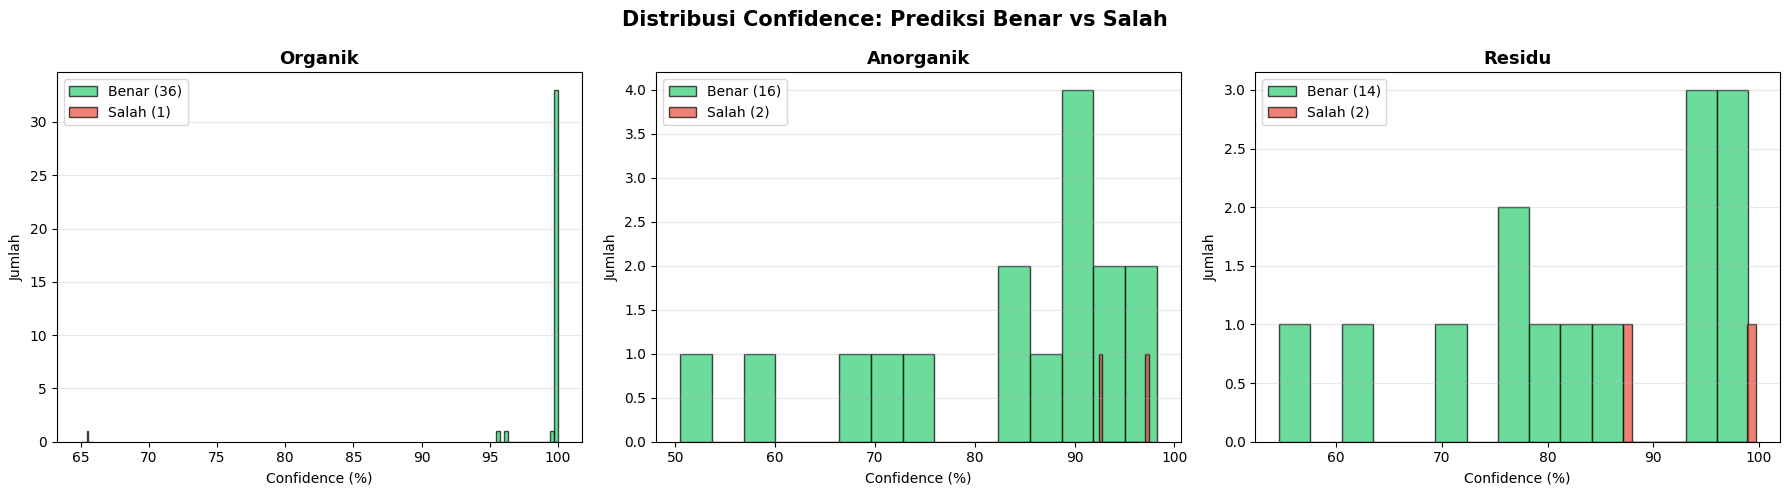

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, label in enumerate(FINAL_LABELS):
    ax = axes[idx]
    
    # Confidence untuk prediksi benar
    conf_correct = [r['model1_conf'] if r['final_label'] == 'Organik' else r['model2_conf']
                    for r in valid_results 
                    if r['true_label'] == label and r['correct'] and r.get('model1_conf') is not None]
    
    # Confidence untuk prediksi salah
    conf_wrong = [r['model1_conf'] if r['final_label'] == 'Organik' else (r['model2_conf'] if r.get('model2_conf') else r['model1_conf'])
                  for r in valid_results 
                  if r['true_label'] == label and not r['correct'] and r.get('model1_conf') is not None]
    
    if conf_correct:
        ax.hist(conf_correct, bins=15, alpha=0.7, color='#2ecc71', edgecolor='black', label=f'Benar ({len(conf_correct)})')
    if conf_wrong:
        ax.hist(conf_wrong, bins=15, alpha=0.7, color='#e74c3c', edgecolor='black', label=f'Salah ({len(conf_wrong)})')
    
    ax.set_title(f'{label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Confidence (%)')
    ax.set_ylabel('Jumlah')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribusi Confidence: Prediksi Benar vs Salah', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Box Plot Confidence per Kelas (Benar vs Salah)

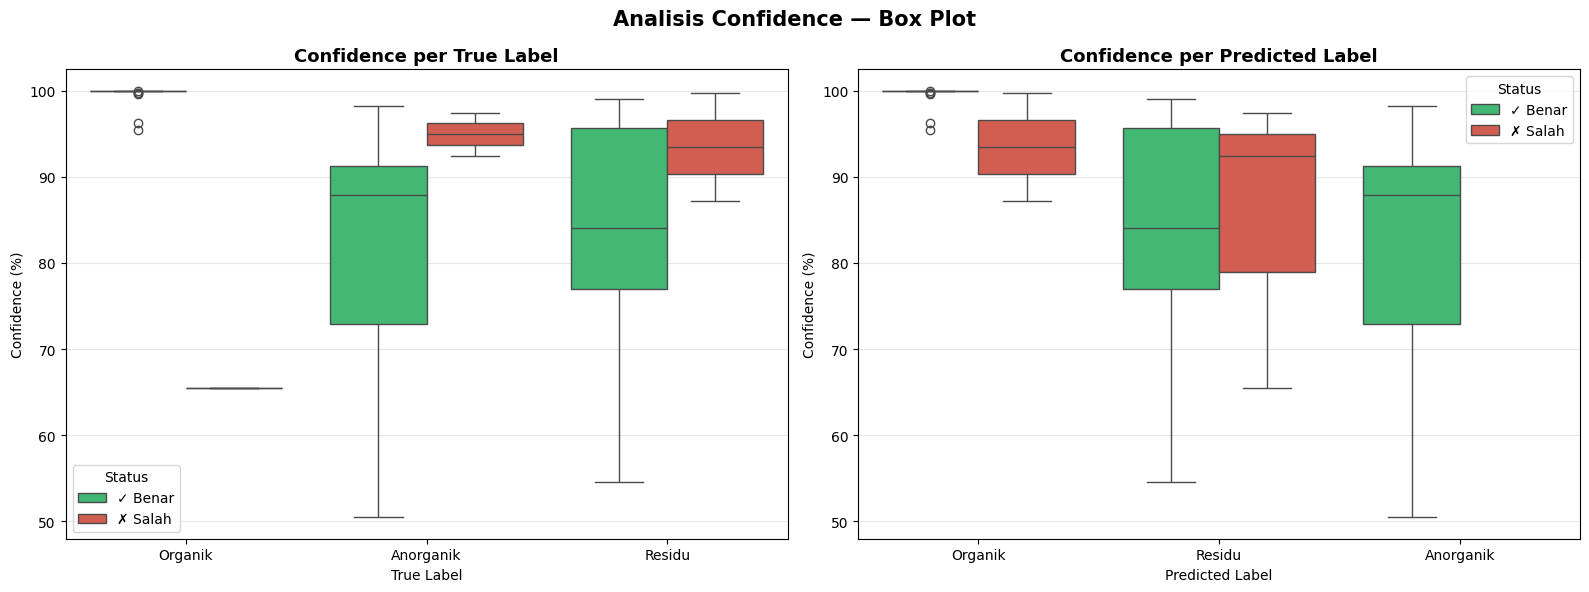

In [ ]:
import pandas as pd

# Kumpulkan data confidence untuk boxplot
box_data = []
for r in valid_results:
    if r['final_label'] == 'Organik':
        conf = r['model1_conf']
    elif r.get('model2_conf') is not None:
        conf = r['model2_conf']
    else:
        conf = r['model1_conf']
    
    box_data.append({
        'True Label': r['true_label'],
        'Predicted Label': r['final_label'],
        'Confidence': conf,
        'Status': '✓ Benar' if r['correct'] else '✗ Salah'
    })

df_box = pd.DataFrame(box_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot per True Label
sns.boxplot(data=df_box, x='True Label', y='Confidence', hue='Status',
            palette={'✓ Benar': '#2ecc71', '✗ Salah': '#e74c3c'}, ax=ax1)
ax1.set_title('Confidence per True Label', fontsize=13, fontweight='bold')
ax1.set_ylabel('Confidence (%)')
ax1.grid(axis='y', alpha=0.3)

# Box plot per Predicted Label  
sns.boxplot(data=df_box, x='Predicted Label', y='Confidence', hue='Status',
            palette={'✓ Benar': '#2ecc71', '✗ Salah': '#e74c3c'}, ax=ax2)
ax2.set_title('Confidence per Predicted Label', fontsize=13, fontweight='bold')
ax2.set_ylabel('Confidence (%)')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Analisis Confidence — Box Plot', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Akurasi per Kelas — Bar Chart + Overall

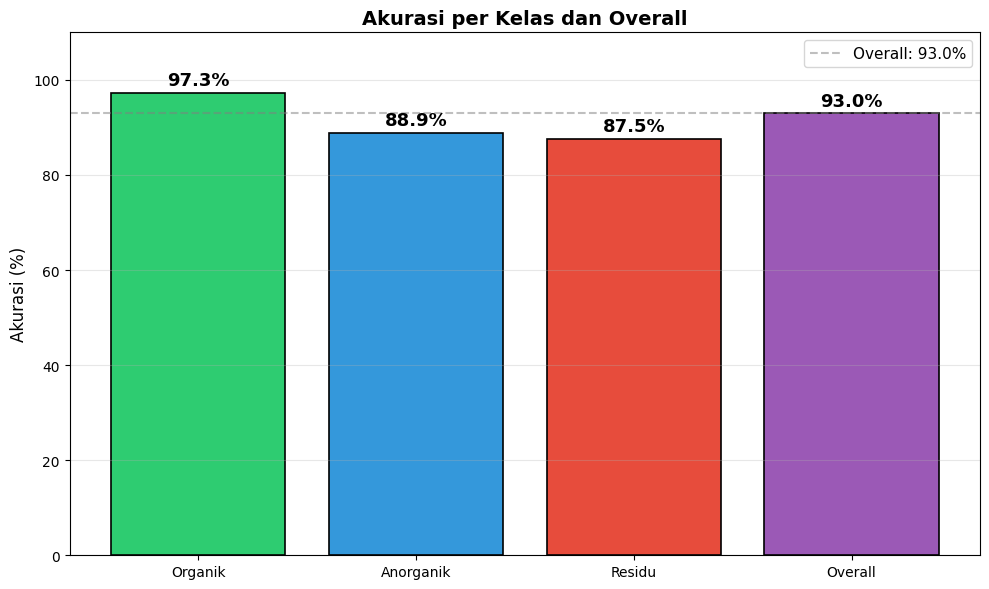

In [ ]:
overall_acc = accuracy_score(y_true, y_pred)

class_acc = []
for label in FINAL_LABELS:
    mask = [t == label for t in y_true]
    if sum(mask) > 0:
        correct_cls = sum(1 for t, p in zip(y_true, y_pred) if t == label and p == label)
        total_cls = sum(mask)
        class_acc.append(correct_cls / total_cls)
    else:
        class_acc.append(0)

fig, ax = plt.subplots(figsize=(10, 6))

labels_plot = FINAL_LABELS + ['Overall']
values_plot = class_acc + [overall_acc]
colors_plot = [LABEL_COLORS[l] for l in FINAL_LABELS] + ['#9b59b6']

bars = ax.bar(labels_plot, [v * 100 for v in values_plot], color=colors_plot, edgecolor='black', linewidth=1.2)

for bar, val in zip(bars, values_plot):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.8,
            f'{val*100:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_ylim(0, 110)
ax.set_ylabel('Akurasi (%)', fontsize=12)
ax.set_title('Akurasi per Kelas dan Overall', fontsize=14, fontweight='bold')
ax.axhline(y=overall_acc * 100, color='gray', linestyle='--', alpha=0.5, label=f'Overall: {overall_acc*100:.1f}%')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 16. Analisis Error: Tipe Kesalahan Hierarki

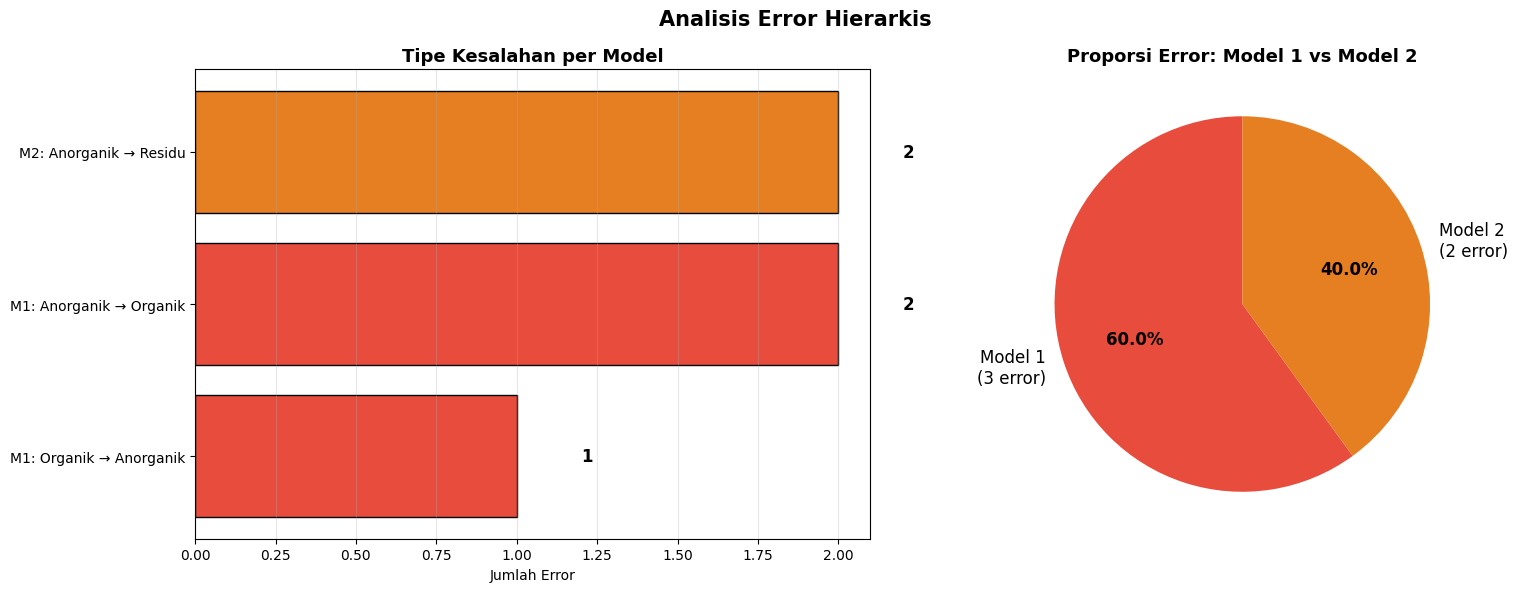

In [ ]:
# Kategorikan kesalahan
error_types = {
    'M1: Organik → Anorganik': 0,   # Model 1 salah: seharusnya Organik tapi diprediksi Anorganik
    'M1: Anorganik → Organik': 0,   # Model 1 salah: seharusnya Anorganik/Residu tapi diprediksi Organik
    'M2: Anorganik → Residu': 0,    # Model 2 salah: seharusnya Anorganik tapi diprediksi Residu
    'M2: Residu → Anorganik': 0,    # Model 2 salah: seharusnya Residu tapi diprediksi Anorganik
}

for r in valid_results:
    if r['correct']:
        continue
    true_l = r['true_label']
    pred_l = r['final_label']
    m1_pred = r['model1_pred']
    
    # Kesalahan di Model 1: true Organik tapi Model 1 bilang Anorganik
    if true_l == 'Organik' and m1_pred == 'Anorganik':
        error_types['M1: Organik → Anorganik'] += 1
    # Kesalahan di Model 1: true Anorganik/Residu tapi Model 1 bilang Organik
    elif true_l in ['Anorganik', 'Residu'] and m1_pred == 'Organik':
        error_types['M1: Anorganik → Organik'] += 1
    # Kesalahan di Model 2: true Anorganik tapi Model 2 bilang Residu
    elif true_l == 'Anorganik' and pred_l == 'Residu':
        error_types['M2: Anorganik → Residu'] += 1
    # Kesalahan di Model 2: true Residu tapi Model 2 bilang Anorganik
    elif true_l == 'Residu' and pred_l == 'Anorganik':
        error_types['M2: Residu → Anorganik'] += 1

# Filter hanya yang punya error
error_labels = [k for k, v in error_types.items() if v > 0]
error_values = [error_types[k] for k in error_labels]

if error_labels:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar chart tipe error
    err_colors = ['#e74c3c' if 'M1' in l else '#e67e22' for l in error_labels]
    bars = ax1.barh(error_labels, error_values, color=err_colors, edgecolor='black')
    for bar, val in zip(bars, error_values):
        ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2.,
                 str(val), va='center', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Jumlah Error')
    ax1.set_title('Tipe Kesalahan per Model', fontsize=13, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Pie chart: error di Model 1 vs Model 2
    m1_errors = sum(v for k, v in error_types.items() if 'M1' in k)
    m2_errors = sum(v for k, v in error_types.items() if 'M2' in k)
    
    if m1_errors + m2_errors > 0:
        pie_labels = []
        pie_sizes = []
        pie_colors = []
        if m1_errors > 0:
            pie_labels.append(f'Model 1\n({m1_errors} error)')
            pie_sizes.append(m1_errors)
            pie_colors.append('#e74c3c')
        if m2_errors > 0:
            pie_labels.append(f'Model 2\n({m2_errors} error)')
            pie_sizes.append(m2_errors)
            pie_colors.append('#e67e22')
        
        wedges, texts, autotexts = ax2.pie(
            pie_sizes, labels=pie_labels, autopct='%1.1f%%',
            colors=pie_colors, startangle=90, textprops={'fontsize': 12}
        )
        for at in autotexts:
            at.set_fontweight('bold')
        ax2.set_title('Proporsi Error: Model 1 vs Model 2', fontsize=13, fontweight='bold')
    else:
        ax2.text(0.5, 0.5, 'Tidak ada error!', ha='center', va='center',
                 fontsize=16, transform=ax2.transAxes)
        ax2.set_title('Proporsi Error', fontsize=13, fontweight='bold')
    
    plt.suptitle('Analisis Error Hierarkis', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("🎉 Tidak ada error — semua prediksi benar!")

## 17. Heatmap Confidence: True Label vs Predicted Label

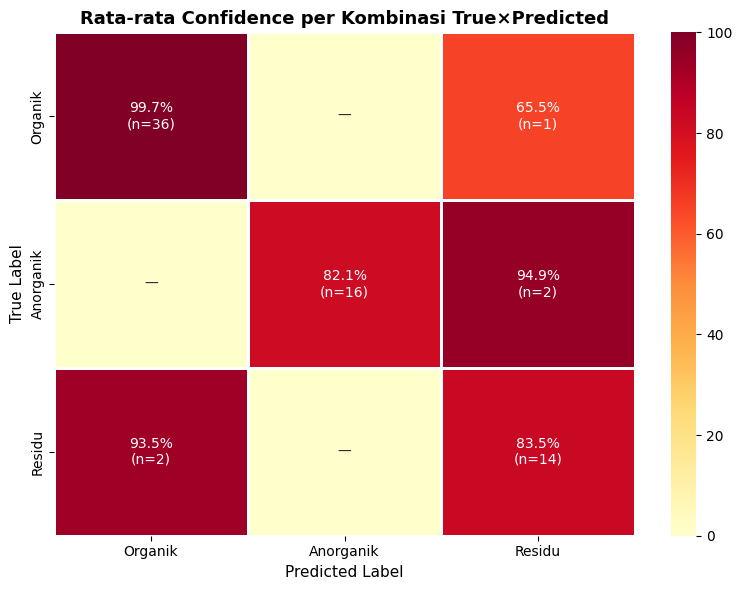

In [ ]:
# Hitung rata-rata confidence untuk setiap kombinasi True x Predicted
conf_matrix_avg = np.zeros((len(FINAL_LABELS), len(FINAL_LABELS)))
conf_matrix_count = np.zeros((len(FINAL_LABELS), len(FINAL_LABELS)))

for r in valid_results:
    true_idx = FINAL_LABELS.index(r['true_label'])
    pred_idx = FINAL_LABELS.index(r['final_label'])
    
    if r['final_label'] == 'Organik':
        conf = r['model1_conf']
    elif r.get('model2_conf') is not None:
        conf = r['model2_conf']
    else:
        conf = r['model1_conf']
    
    conf_matrix_avg[true_idx, pred_idx] += conf
    conf_matrix_count[true_idx, pred_idx] += 1

# Hindari division by zero
with np.errstate(divide='ignore', invalid='ignore'):
    conf_matrix_avg = np.where(conf_matrix_count > 0, 
                                conf_matrix_avg / conf_matrix_count, 0)

fig, ax = plt.subplots(figsize=(8, 6))

# Buat annotation: avg confidence + count
annot = []
for i in range(len(FINAL_LABELS)):
    row = []
    for j in range(len(FINAL_LABELS)):
        cnt = int(conf_matrix_count[i, j])
        avg = conf_matrix_avg[i, j]
        if cnt > 0:
            row.append(f'{avg:.1f}%\n(n={cnt})')
        else:
            row.append('—')
    annot.append(row)

sns.heatmap(conf_matrix_avg, annot=annot, fmt='', cmap='YlOrRd',
            xticklabels=FINAL_LABELS, yticklabels=FINAL_LABELS,
            vmin=0, vmax=100, ax=ax, linewidths=1, linecolor='white')
ax.set_title('Rata-rata Confidence per Kombinasi True×Predicted', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.show()

## 18. Visualisasi Alur Hierarki — Stacked Bar (Sankey-Style)

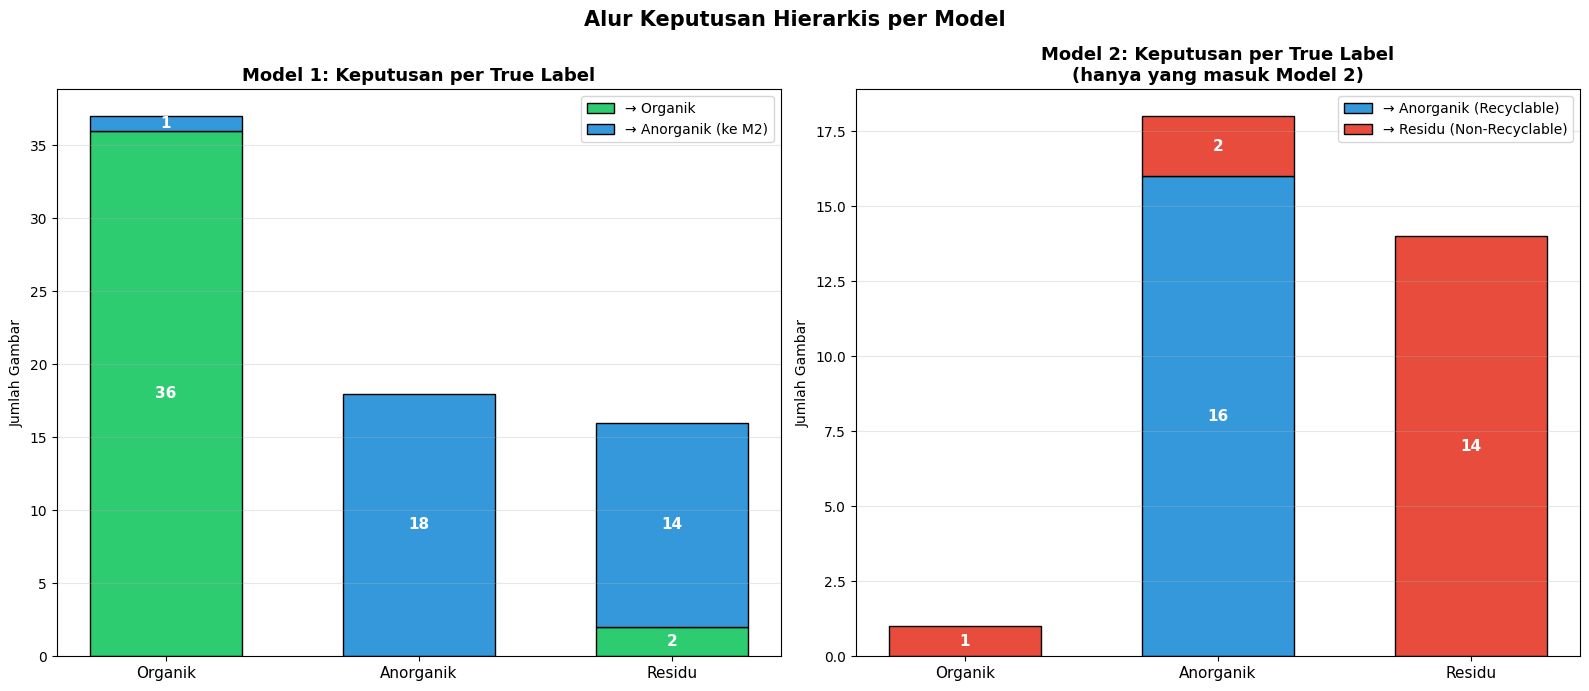

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ===== Chart 1: Model 1 Decision per True Label =====
ax = axes[0]
m1_data = {}
for label in FINAL_LABELS:
    subset = [r for r in valid_results if r['true_label'] == label]
    m1_data[label] = {
        'Organik': sum(1 for r in subset if r['model1_pred'] == 'Organik'),
        'Anorganik': sum(1 for r in subset if r['model1_pred'] == 'Anorganik')
    }

organik_vals = [m1_data[l]['Organik'] for l in FINAL_LABELS]
anorganik_vals = [m1_data[l]['Anorganik'] for l in FINAL_LABELS]

x_pos = np.arange(len(FINAL_LABELS))
b1 = ax.bar(x_pos, organik_vals, 0.6, label='→ Organik', color='#2ecc71', edgecolor='black')
b2 = ax.bar(x_pos, anorganik_vals, 0.6, bottom=organik_vals, label='→ Anorganik (ke M2)', color='#3498db', edgecolor='black')

for i in range(len(FINAL_LABELS)):
    total_i = organik_vals[i] + anorganik_vals[i]
    if organik_vals[i] > 0:
        ax.text(i, organik_vals[i]/2, str(organik_vals[i]), ha='center', va='center', fontweight='bold', fontsize=11, color='white')
    if anorganik_vals[i] > 0:
        ax.text(i, organik_vals[i] + anorganik_vals[i]/2, str(anorganik_vals[i]), ha='center', va='center', fontweight='bold', fontsize=11, color='white')

ax.set_xticks(x_pos)
ax.set_xticklabels(FINAL_LABELS, fontsize=11)
ax.set_ylabel('Jumlah Gambar')
ax.set_title('Model 1: Keputusan per True Label', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

# ===== Chart 2: Model 2 Decision per True Label (hanya yang masuk M2) =====
ax = axes[1]
m2_labels_present = []
recyclable_vals = []
residu_vals = []

for label in FINAL_LABELS:
    subset = [r for r in valid_results if r['true_label'] == label and r['model1_pred'] == 'Anorganik']
    if len(subset) == 0:
        continue
    m2_labels_present.append(label)
    recyclable_vals.append(sum(1 for r in subset if r['model2_pred'] == 'Anorganik'))
    residu_vals.append(sum(1 for r in subset if r['model2_pred'] == 'Residu'))

if m2_labels_present:
    x_pos2 = np.arange(len(m2_labels_present))
    b1 = ax.bar(x_pos2, recyclable_vals, 0.6, label='→ Anorganik (Recyclable)', color='#3498db', edgecolor='black')
    b2 = ax.bar(x_pos2, residu_vals, 0.6, bottom=recyclable_vals, label='→ Residu (Non-Recyclable)', color='#e74c3c', edgecolor='black')
    
    for i in range(len(m2_labels_present)):
        if recyclable_vals[i] > 0:
            ax.text(i, recyclable_vals[i]/2, str(recyclable_vals[i]), ha='center', va='center', fontweight='bold', fontsize=11, color='white')
        if residu_vals[i] > 0:
            ax.text(i, recyclable_vals[i] + residu_vals[i]/2, str(residu_vals[i]), ha='center', va='center', fontweight='bold', fontsize=11, color='white')
    
    ax.set_xticks(x_pos2)
    ax.set_xticklabels(m2_labels_present, fontsize=11)
    ax.set_ylabel('Jumlah Gambar')
    ax.set_title('Model 2: Keputusan per True Label\n(hanya yang masuk Model 2)', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Tidak ada data yang masuk Model 2', ha='center', va='center',
            fontsize=14, transform=ax.transAxes)

plt.suptitle('Alur Keputusan Hierarkis per Model', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 19. Scatter Plot: Confidence Model 1 vs Model 2

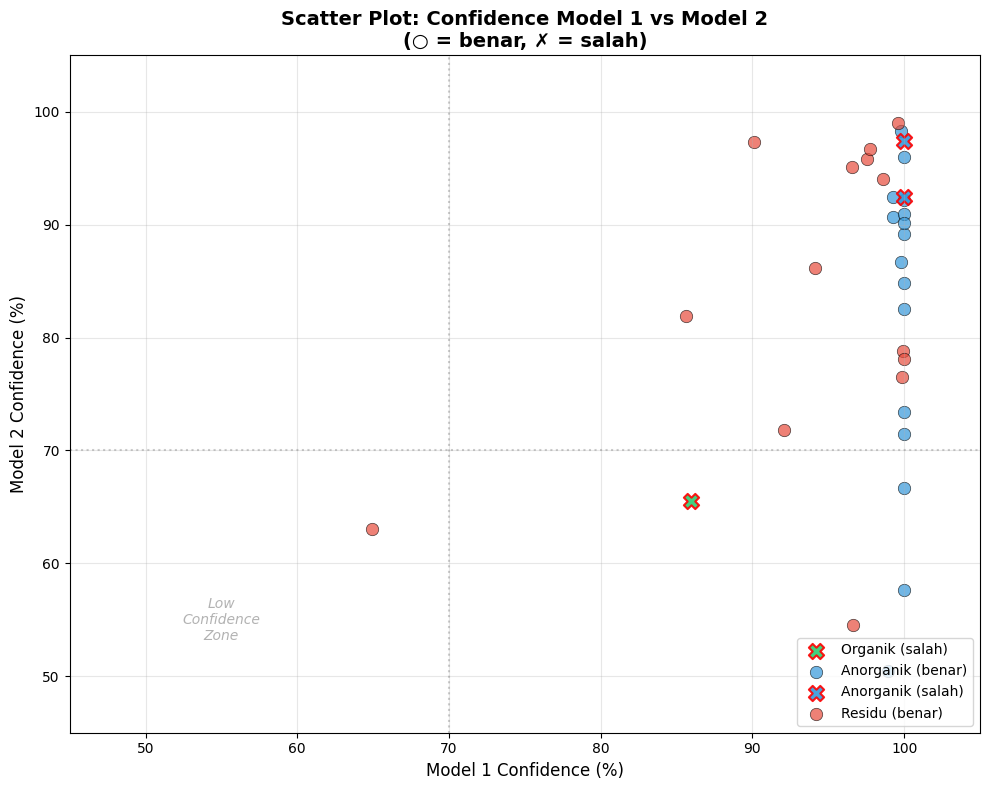

In [ ]:
# Hanya data yang melewati kedua model
dual_model_results = [r for r in valid_results if r.get('model2_conf') is not None]

if dual_model_results:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    for label in FINAL_LABELS:
        subset = [r for r in dual_model_results if r['true_label'] == label]
        if not subset:
            continue
        m1_confs = [r['model1_conf'] for r in subset]
        m2_confs = [r['model2_conf'] for r in subset]
        correct_markers = ['o' if r['correct'] else 'X' for r in subset]
        
        # Plot benar
        correct_sub = [r for r in subset if r['correct']]
        if correct_sub:
            ax.scatter([r['model1_conf'] for r in correct_sub],
                       [r['model2_conf'] for r in correct_sub],
                       c=LABEL_COLORS[label], marker='o', s=80, alpha=0.7,
                       label=f'{label} (benar)', edgecolors='black', linewidth=0.5)
        # Plot salah
        wrong_sub = [r for r in subset if not r['correct']]
        if wrong_sub:
            ax.scatter([r['model1_conf'] for r in wrong_sub],
                       [r['model2_conf'] for r in wrong_sub],
                       c=LABEL_COLORS[label], marker='X', s=120, alpha=0.9,
                       label=f'{label} (salah)', edgecolors='red', linewidth=1.5)
    
    ax.set_xlabel('Model 1 Confidence (%)', fontsize=12)
    ax.set_ylabel('Model 2 Confidence (%)', fontsize=12)
    ax.set_title('Scatter Plot: Confidence Model 1 vs Model 2\n(○ = benar, ✗ = salah)', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(45, 105)
    ax.set_ylim(45, 105)
    
    # Zona confidence rendah
    ax.axhline(y=70, color='gray', linestyle=':', alpha=0.4)
    ax.axvline(x=70, color='gray', linestyle=':', alpha=0.4)
    ax.text(55, 55, 'Low\nConfidence\nZone', ha='center', va='center', 
            fontsize=10, color='gray', alpha=0.6, fontstyle='italic')
    
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Tidak ada data yang melewati kedua model (semua diprediksi Organik oleh Model 1).")

## 20. Visualisasi Prediksi Salah (Gambar)

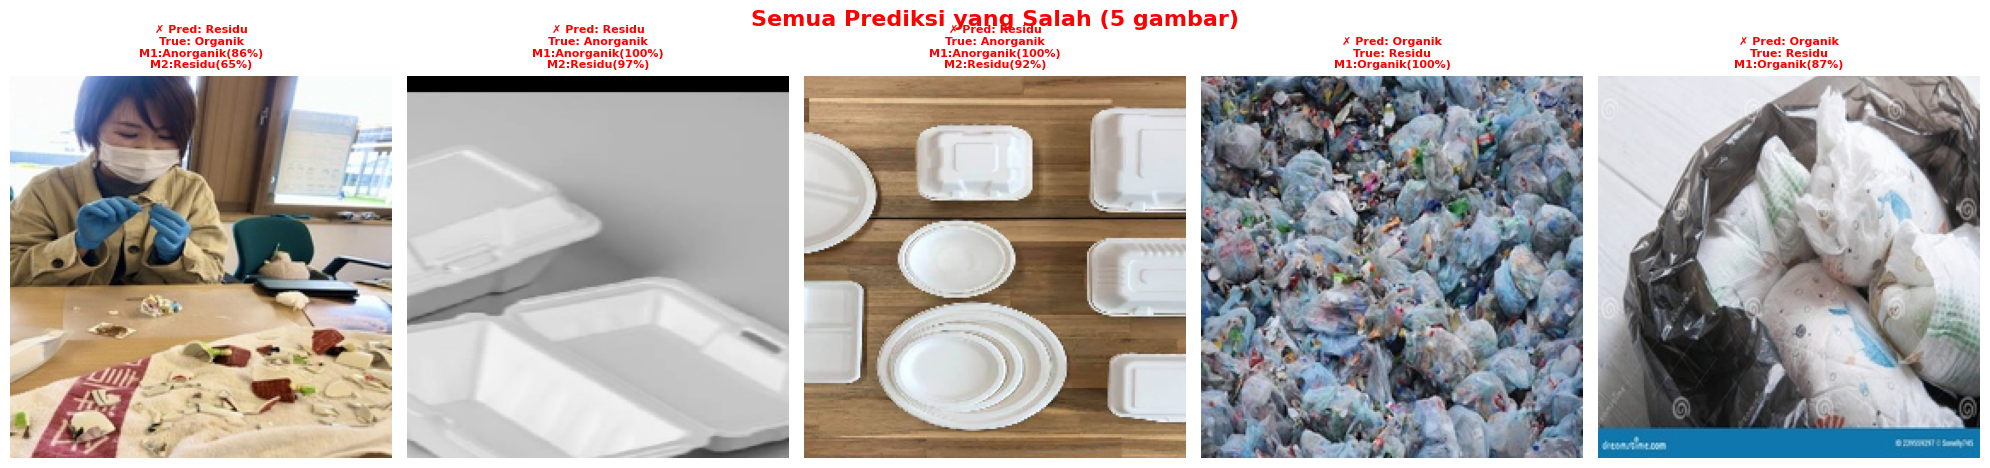

In [ ]:
wrong_results = [r for r in valid_results if not r['correct']]

if wrong_results:
    n_wrong = len(wrong_results)
    n_cols_w = min(5, n_wrong)
    n_rows_w = (n_wrong + n_cols_w - 1) // n_cols_w
    
    fig, axes = plt.subplots(n_rows_w, n_cols_w, figsize=(4 * n_cols_w, 5 * n_rows_w))
    if n_rows_w == 1 and n_cols_w == 1:
        axes_flat = [axes]
    elif n_rows_w == 1:
        axes_flat = list(axes)
    else:
        axes_flat = [ax for row in axes for ax in row]
    
    for idx, r in enumerate(wrong_results):
        ax = axes_flat[idx]
        try:
            img = load_img(r['image_path'], target_size=IMG_SIZE)
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, 'Error', ha='center', va='center', transform=ax.transAxes)
        
        m1_info = f"M1:{r['model1_pred']}({r['model1_conf']:.0f}%)"
        m2_info = f"\nM2:{r['model2_pred']}({r['model2_conf']:.0f}%)" if r.get('model2_pred') else ''
        
        ax.set_title(
            f"✗ Pred: {r['final_label']}\nTrue: {r['true_label']}\n{m1_info}{m2_info}",
            fontsize=8, color='red', fontweight='bold'
        )
        ax.axis('off')
    
    for idx in range(len(wrong_results), len(axes_flat)):
        axes_flat[idx].axis('off')
    
    plt.suptitle(f'Semua Prediksi yang Salah ({n_wrong} gambar)', fontsize=16, fontweight='bold', color='red')
    plt.tight_layout()
    plt.show()
else:
    print("🎉 Tidak ada prediksi yang salah!")

## 21. Metrik Tambahan: Cohen's Kappa, MCC, Weighted/Macro Average

METRIK EVALUASI LENGKAP

  Overall Accuracy      : 0.9296 (92.96%)
  Balanced Accuracy     : 0.9123 (91.23%)
  Cohen's Kappa         : 0.8846
  Matthews Corr. Coeff. : 0.8854

  Macro Precision       : 0.9236
  Macro Recall          : 0.9123
  Macro F1-Score        : 0.9166

  Weighted Precision    : 0.9328
  Weighted Recall       : 0.9296
  Weighted F1-Score     : 0.9301



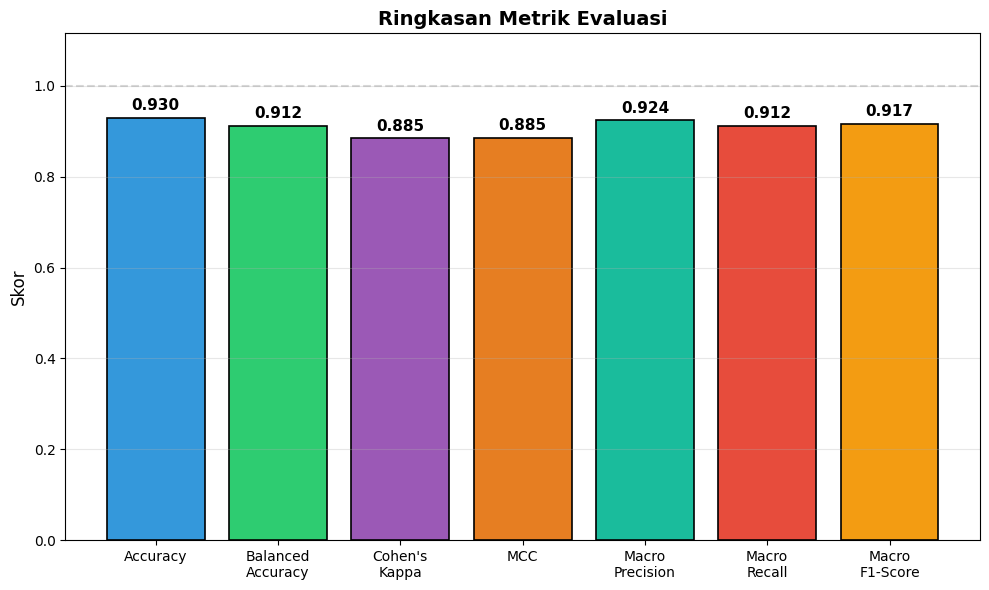

In [ ]:
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(FINAL_LABELS)
y_true_enc = le.transform(y_true)
y_pred_enc = le.transform(y_pred)

kappa = cohen_kappa_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true_enc, y_pred_enc)
balanced_acc = balanced_accuracy_score(y_true, y_pred)

# Macro & Weighted averages
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print("=" * 60)
print("METRIK EVALUASI LENGKAP")
print("=" * 60)
print(f"")
print(f"  Overall Accuracy      : {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print(f"  Balanced Accuracy     : {balanced_acc:.4f} ({balanced_acc*100:.2f}%)")
print(f"  Cohen's Kappa         : {kappa:.4f}")
print(f"  Matthews Corr. Coeff. : {mcc:.4f}")
print(f"")
print(f"  Macro Precision       : {prec_macro:.4f}")
print(f"  Macro Recall          : {rec_macro:.4f}")
print(f"  Macro F1-Score        : {f1_macro:.4f}")
print(f"")
print(f"  Weighted Precision    : {prec_weighted:.4f}")
print(f"  Weighted Recall       : {rec_weighted:.4f}")
print(f"  Weighted F1-Score     : {f1_weighted:.4f}")
print(f"")

# Visualisasi metrik utama
fig, ax = plt.subplots(figsize=(10, 6))

metric_names = ['Accuracy', 'Balanced\nAccuracy', "Cohen's\nKappa", 'MCC',
                'Macro\nPrecision', 'Macro\nRecall', 'Macro\nF1-Score']
metric_values = [overall_acc, balanced_acc, kappa, mcc, prec_macro, rec_macro, f1_macro]
metric_colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#1abc9c', '#e74c3c', '#f39c12']

bars = ax.bar(metric_names, metric_values, color=metric_colors, edgecolor='black', linewidth=1.2)

for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, max(metric_values) * 1.2 if max(metric_values) > 0 else 1.0)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Ringkasan Metrik Evaluasi', fontsize=14, fontweight='bold')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 22. Radar Chart: Perbandingan Performa per Kelas

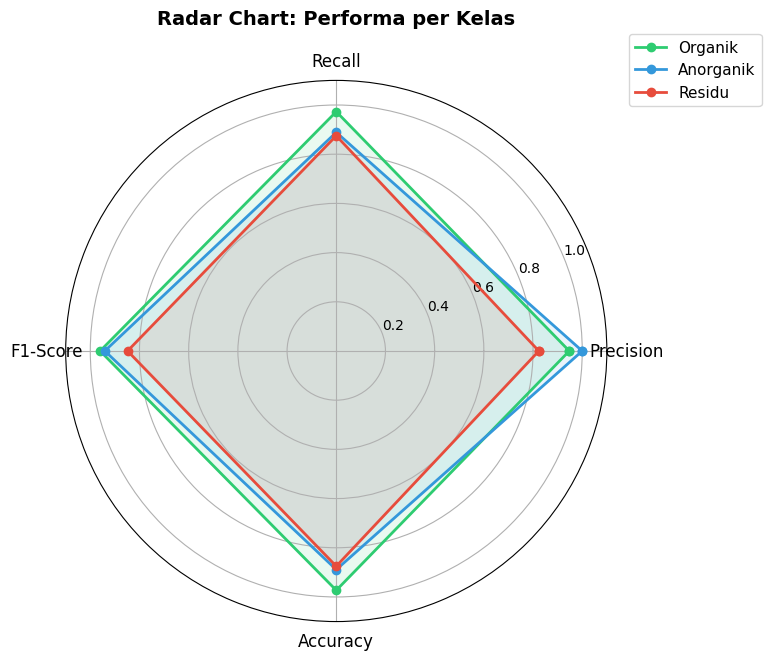

In [ ]:
from matplotlib.patches import FancyBboxPatch

# Data per kelas
categories_radar = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
n_cats = len(categories_radar)

angles = [n / float(n_cats) * 2 * np.pi for n in range(n_cats)]
angles += angles[:1]  # tutup polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, label in enumerate(FINAL_LABELS):
    values = [precision[i], recall[i], f1[i], class_acc[i]]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=label, color=LABEL_COLORS[label])
    ax.fill(angles, values, alpha=0.1, color=LABEL_COLORS[label])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories_radar, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('Radar Chart: Performa per Kelas', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True)

plt.tight_layout()
plt.show()

## 23. Tabel Ringkasan Lengkap

TABEL RINGKASAN LENGKAP
    Kelas  Total Aktual  Total Prediksi  TP  FP  FN  TN Precision Recall F1-Score Accuracy
  Organik            37              38  36   2   1  32    0.9474 0.9730   0.9600   0.9730
Anorganik            18              16  16   0   2  53    1.0000 0.8889   0.9412   0.8889
   Residu            16              17  14   3   2  52    0.8235 0.8750   0.8485   0.8750




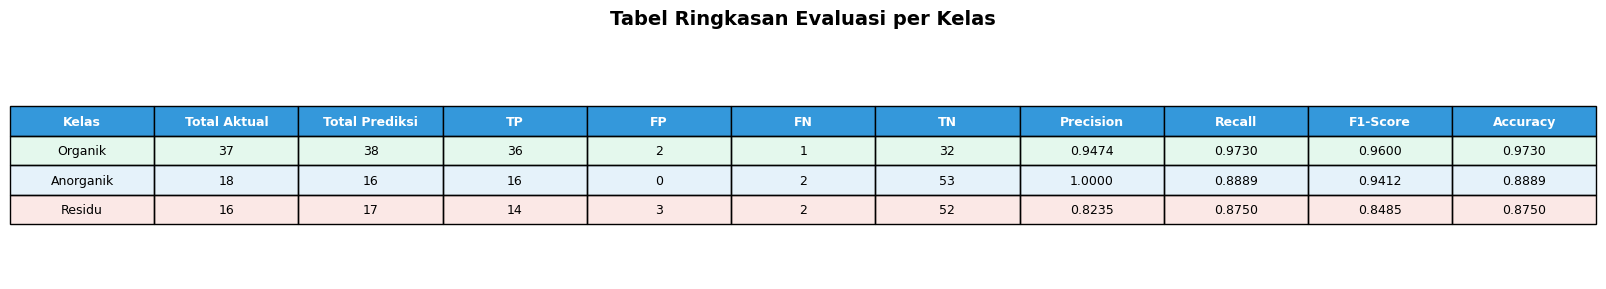

In [ ]:
# Buat tabel ringkasan
summary_data = []
for i, label in enumerate(FINAL_LABELS):
    total_true = sum(1 for t in y_true if t == label)
    total_pred = sum(1 for p in y_pred if p == label)
    tp = sum(1 for t, p in zip(y_true, y_pred) if t == label and p == label)
    fp = sum(1 for t, p in zip(y_true, y_pred) if t != label and p == label)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t == label and p != label)
    tn = sum(1 for t, p in zip(y_true, y_pred) if t != label and p != label)
    
    summary_data.append({
        'Kelas': label,
        'Total Aktual': total_true,
        'Total Prediksi': total_pred,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'Precision': f'{precision[i]:.4f}',
        'Recall': f'{recall[i]:.4f}',
        'F1-Score': f'{f1[i]:.4f}',
        'Accuracy': f'{class_acc[i]:.4f}'
    })

df_summary = pd.DataFrame(summary_data)
print("=" * 90)
print("TABEL RINGKASAN LENGKAP")
print("=" * 90)
print(df_summary.to_string(index=False))
print("\n")

# Visualisasi tabel
fig, ax = plt.subplots(figsize=(16, 3))
ax.axis('off')

table_data = [df_summary.columns.tolist()] + df_summary.values.tolist()
table = ax.table(
    cellText=df_summary.values.tolist(),
    colLabels=df_summary.columns.tolist(),
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

# Style header
for j in range(len(df_summary.columns)):
    table[0, j].set_facecolor('#3498db')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Style rows
row_colors = [LABEL_COLORS[l] for l in FINAL_LABELS]
for i in range(len(FINAL_LABELS)):
    for j in range(len(df_summary.columns)):
        table[i+1, j].set_facecolor(row_colors[i] + '20')  # transparan

ax.set_title('Tabel Ringkasan Evaluasi per Kelas', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 24. Dashboard Ringkasan Akhir

C:\Users\rika\AppData\Local\Temp\ipykernel_29192\3787403375.py:104: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
C:\Users\rika\AppData\Local\Temp\ipykernel_29192\3787403375.py:104: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
C:\Users\rika\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rika\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


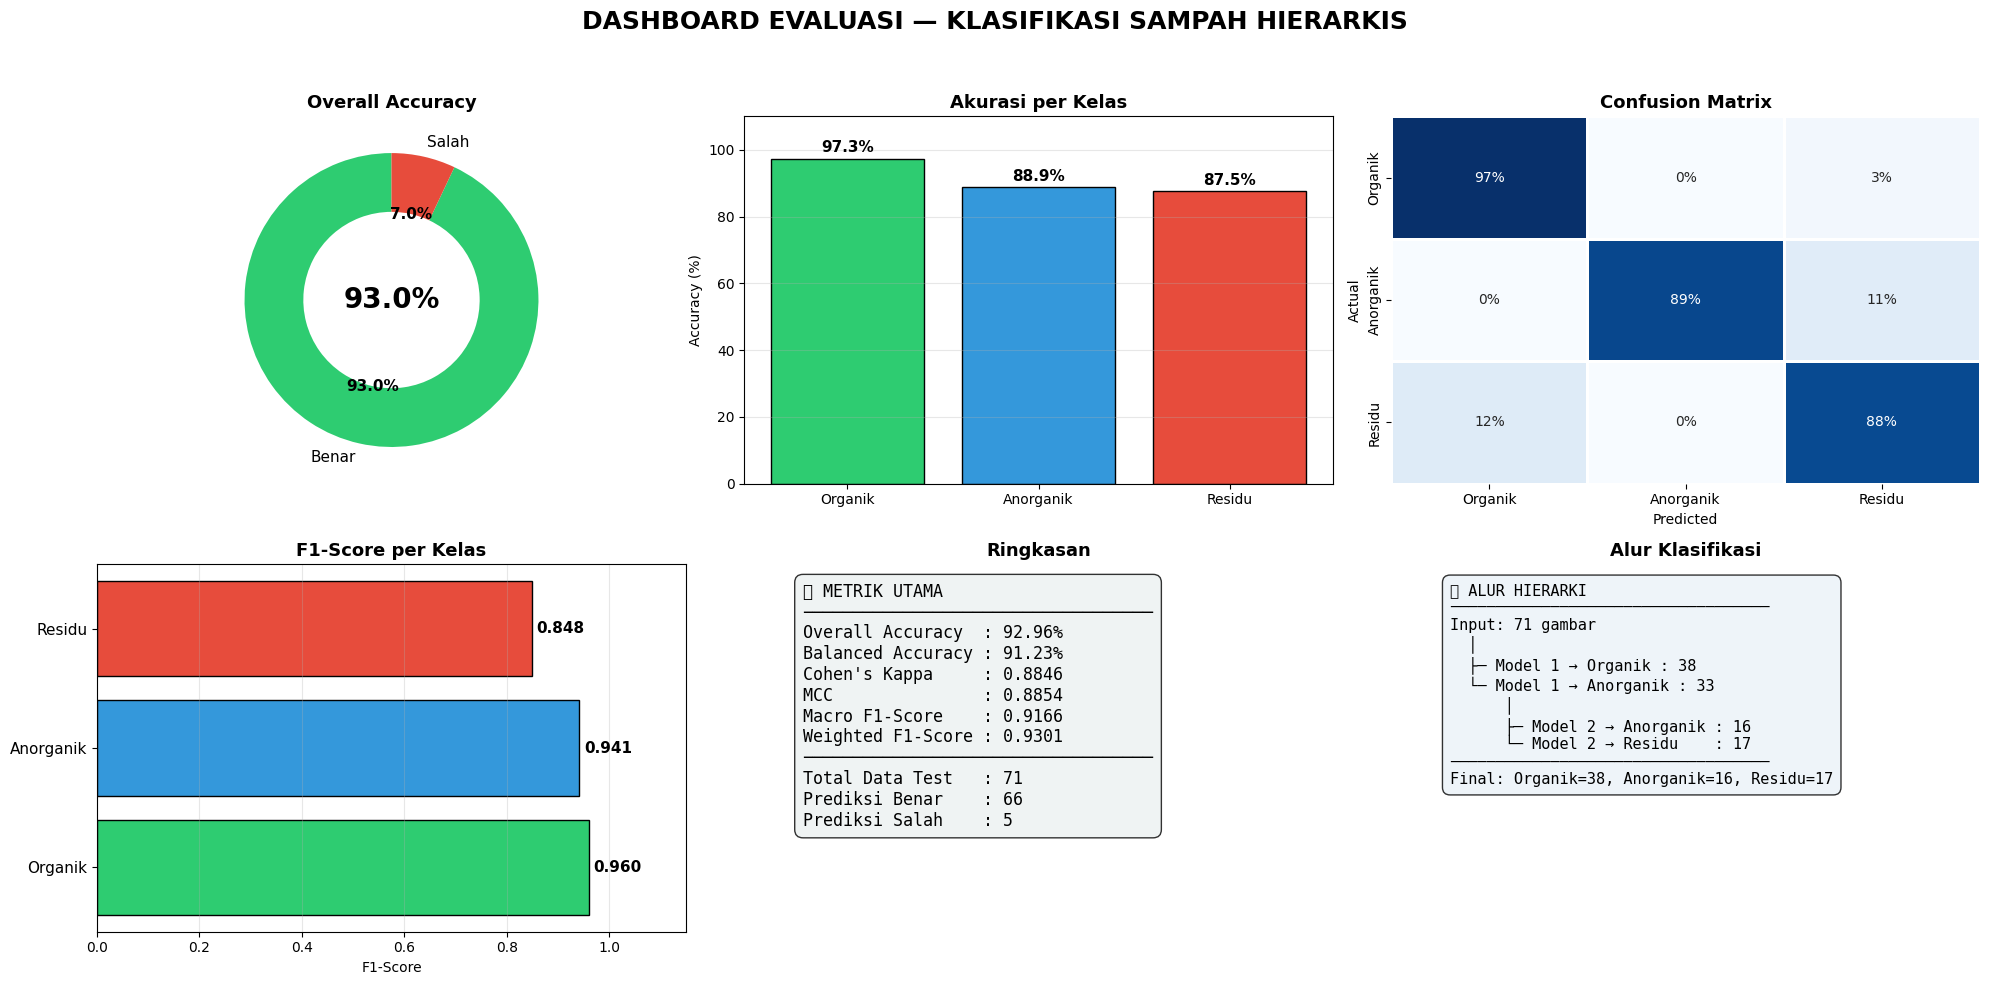

In [ ]:
fig = plt.figure(figsize=(20, 10))
fig.suptitle('DASHBOARD EVALUASI — KLASIFIKASI SAMPAH HIERARKIS', fontsize=18, fontweight='bold', y=0.98)

# --- Subplot 1: Donut Chart Overall Accuracy ---
ax1 = fig.add_subplot(2, 3, 1)
correct_n = sum(1 for t, p in zip(y_true, y_pred) if t == p)
wrong_n = len(y_true) - correct_n
sizes = [correct_n, wrong_n]
colors_donut = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax1.pie(sizes, labels=['Benar', 'Salah'], autopct='%1.1f%%',
                                     colors=colors_donut, startangle=90,
                                     wedgeprops=dict(width=0.4), textprops={'fontsize': 11})
for at in autotexts:
    at.set_fontweight('bold')
ax1.text(0, 0, f'{overall_acc*100:.1f}%', ha='center', va='center', fontsize=20, fontweight='bold')
ax1.set_title('Overall Accuracy', fontsize=13, fontweight='bold')

# --- Subplot 2: Bar per kelas ---
ax2 = fig.add_subplot(2, 3, 2)
bars = ax2.bar(FINAL_LABELS, [a*100 for a in class_acc],
               color=[LABEL_COLORS[l] for l in FINAL_LABELS], edgecolor='black')
for bar, val in zip(bars, class_acc):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val*100:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.set_ylim(0, 110)
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Akurasi per Kelas', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# --- Subplot 3: Confusion Matrix mini ---
ax3 = fig.add_subplot(2, 3, 3)
sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap='Blues',
            xticklabels=FINAL_LABELS, yticklabels=FINAL_LABELS, ax=ax3,
            cbar=False, linewidths=1, linecolor='white')
ax3.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

# --- Subplot 4: F1-Score horizontal ---
ax4 = fig.add_subplot(2, 3, 4)
y_pos_f1 = np.arange(len(FINAL_LABELS))
bars = ax4.barh(y_pos_f1, f1, color=[LABEL_COLORS[l] for l in FINAL_LABELS], edgecolor='black')
for bar, val in zip(bars, f1):
    ax4.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2.,
             f'{val:.3f}', va='center', fontweight='bold', fontsize=11)
ax4.set_yticks(y_pos_f1)
ax4.set_yticklabels(FINAL_LABELS, fontsize=11)
ax4.set_xlim(0, 1.15)
ax4.set_xlabel('F1-Score')
ax4.set_title('F1-Score per Kelas', fontsize=13, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

# --- Subplot 5: Key Metrics ---
ax5 = fig.add_subplot(2, 3, 5)
ax5.axis('off')
metrics_text = (
    f"📊 METRIK UTAMA\n"
    f"{'─'*35}\n"
    f"Overall Accuracy  : {overall_acc*100:.2f}%\n"
    f"Balanced Accuracy : {balanced_acc*100:.2f}%\n"
    f"Cohen's Kappa     : {kappa:.4f}\n"
    f"MCC               : {mcc:.4f}\n"
    f"Macro F1-Score    : {f1_macro:.4f}\n"
    f"Weighted F1-Score : {f1_weighted:.4f}\n"
    f"{'─'*35}\n"
    f"Total Data Test   : {len(y_true)}\n"
    f"Prediksi Benar    : {correct_n}\n"
    f"Prediksi Salah    : {wrong_n}"
)
ax5.text(0.1, 0.95, metrics_text, transform=ax5.transAxes,
         fontsize=12, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#ecf0f1', alpha=0.8))
ax5.set_title('Ringkasan', fontsize=13, fontweight='bold')

# --- Subplot 6: Alur hierarki ringkas ---
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
n_total = len(valid_results)
n_m1_org = len(m1_organik)
n_m1_anorg = len(m1_anorganik)
n_m2_rec = len([r for r in m1_anorganik if r['model2_pred'] == 'Anorganik']) if m1_anorganik else 0
n_m2_res = len([r for r in m1_anorganik if r['model2_pred'] == 'Residu']) if m1_anorganik else 0

flow_text = (
    f"🔄 ALUR HIERARKI\n"
    f"{'─'*35}\n"
    f"Input: {n_total} gambar\n"
    f"  │\n"
    f"  ├─ Model 1 → Organik : {n_m1_org}\n"
    f"  └─ Model 1 → Anorganik : {n_m1_anorg}\n"
    f"      │\n"
    f"      ├─ Model 2 → Anorganik : {n_m2_rec}\n"
    f"      └─ Model 2 → Residu    : {n_m2_res}\n"
    f"{'─'*35}\n"
    f"Final: Organik={n_m1_org}, "
    f"Anorganik={n_m2_rec}, "
    f"Residu={n_m2_res}"
)
ax6.text(0.1, 0.95, flow_text, transform=ax6.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#eaf2f8', alpha=0.8))
ax6.set_title('Alur Klasifikasi', fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

---
## 25. Prediksi Gambar Baru (Input Manual)

Ganti `path_gambar` di bawah dengan path gambar yang ingin diuji.

In [ ]:
# ============================================================
# GANTI PATH GAMBAR DI SINI
# ============================================================
path_gambar = r""  # <-- Isi path gambar di sini
# ============================================================

if path_gambar and os.path.exists(path_gambar):
    print(f"Memproses: {os.path.basename(path_gambar)}")
    print("-" * 50)
    
    result = predict_hierarchical(path_gambar, model1, model2, verbose=True)
    
    # Tampilkan gambar + probabilitas
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    img = load_img(path_gambar, target_size=IMG_SIZE)
    ax1.imshow(img)
    ax1.set_title(f"Prediksi Final: {result['final_label']}", 
                  fontsize=14, fontweight='bold',
                  color=LABEL_COLORS.get(result['final_label'], 'black'))
    ax1.axis('off')
    
    # Bar chart probabilitas
    labels_bar = []
    probs_bar = []
    colors_bar = []
    
    # Model 1 probs
    if result['model1_probs']:
        for k, v in result['model1_probs'].items():
            labels_bar.append(f'M1: {k}')
            probs_bar.append(v * 100)
            colors_bar.append('#3498db')
    
    # Model 2 probs (jika ada)
    if result['model2_probs']:
        for k, v in result['model2_probs'].items():
            labels_bar.append(f'M2: {k}')
            probs_bar.append(v * 100)
            colors_bar.append('#e74c3c')
    
    bars = ax2.barh(labels_bar, probs_bar, color=colors_bar)
    ax2.set_xlabel('Probabilitas (%)')
    ax2.set_xlim(0, 105)
    ax2.set_title('Detail Probabilitas per Model', fontweight='bold')
    
    for bar, val in zip(bars, probs_bar):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n🏷️  Label Final: {result['final_label']}")
elif path_gambar:
    print(f"❌ File tidak ditemukan: {path_gambar}")
else:
    print("ℹ️  Silakan isi variabel 'path_gambar' dengan path gambar yang ingin diuji.")

ℹ️  Silakan isi variabel 'path_gambar' dengan path gambar yang ingin diuji.
